In [1]:
!pip install "gymnasium[mujoco]" torch numpy matplotlib

In [3]:
import subprocess, sys

def pip(pkg):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg])

pip("gymnasium")
pip("gymnasium[mujoco]")
pip("torch")
pip("numpy")
pip("matplotlib")
pip("pillow")

# Colab needs a virtual display for rgb_array MuJoCo rendering
import os
IN_COLAB = 'google.colab' in sys.modules or os.path.exists('/content')
if IN_COLAB:
    subprocess.run(["apt-get", "install", "-y", "-q", "xvfb"], capture_output=True)
    pip("pyvirtualdisplay")
    try:
        from pyvirtualdisplay import Display
        _vdisplay = Display(visible=False, size=(400, 300))
        _vdisplay.start()
        print("✓ Virtual display started (Colab)")
    except Exception as e:
        print(f"⚠ Virtual display failed: {e}")

import time
import random
import io
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions.normal import Normal
from torch.distributions.categorical import Categorical

import matplotlib
matplotlib.use('Agg')   # Non-interactive — essential for Kaggle/Colab
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
from collections import deque

from IPython.display import display, clear_output
from PIL import Image

# Env Detection
try:
    import gymnasium as gym
    _e = gym.make("HalfCheetah-v4", render_mode="rgb_array")
    _e.close()
    ENV_ID       = "HalfCheetah-v4"
    IS_CONTINUOUS = True
    print("✓ MuJoCo found — using HalfCheetah-v4")
except Exception:
    import gymnasium as gym
    ENV_ID        = "CartPole-v1"
    IS_CONTINUOUS = False
    print("ℹ MuJoCo not available — using CartPole-v1")

# Hyperparams
SEED           = 42
TOTAL_TIMESTEPS = 500_000 if IS_CONTINUOUS else 150_000
NUM_ENVS       = 4      # parallel envs [ASSUMPTION: single-agent, stationary copies]
NUM_STEPS      = 512    # rollout steps  [ASSUMPTION: episodic / finite horizon]
MINIBATCH_SIZE = 256
UPDATE_EPOCHS  = 4
GAMMA          = 0.99   # [ASSUMPTION: geometric discount — finite effective horizon]
GAE_LAMBDA     = 0.95   # bias-variance tradeoff in advantage estimation
CLIP_COEF      = 0.2    # PPO trust-region proxy [ASSUMPTION: near-stationarity]
ENT_COEF       = 0.01   # [ASSUMPTION: ergodicity — entropy keeps exploration alive]
VF_COEF        = 0.5
MAX_GRAD_NORM  = 0.5
LR             = 3e-4
ANNEAL_LR      = True   # [ASSUMPTION: mild non-stationarity introduced by lr decay]
PLOT_EVERY     = 5      # redraw dashboard every N updates
RENDER_EVERY   = 10     # capture a new env frame every N updates

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# NNs
def layer_init(layer, std=np.sqrt(2), bias_const=0.0):
    nn.init.orthogonal_(layer.weight, std)
    nn.init.constant_(layer.bias, bias_const)
    return layer


class AgentContinuous(nn.Module):
    """
    [ASSUMPTION: Full observability — raw state vector fed in directly, no belief state]
    [ASSUMPTION: Markov property — only current obs used, zero history]
    [ASSUMPTION: Scalar reward — single value head V(s)]
    [ASSUMPTION: Known fixed action space — act_dim set at init and never changes]
    """
    def __init__(self, obs_dim, act_dim):
        super().__init__()
        self.critic = nn.Sequential(
            layer_init(nn.Linear(obs_dim, 256)), nn.Tanh(),
            layer_init(nn.Linear(256, 256)),     nn.Tanh(),
            layer_init(nn.Linear(256, 1), std=1.0),
        )
        self.actor_mean = nn.Sequential(
            layer_init(nn.Linear(obs_dim, 256)), nn.Tanh(),
            layer_init(nn.Linear(256, 256)),     nn.Tanh(),
            layer_init(nn.Linear(256, act_dim), std=0.01),
        )
        self.actor_log_std = nn.Parameter(torch.zeros(1, act_dim))

    def get_value(self, x):
        return self.critic(x)

    def get_action_and_value(self, x, action=None):
        mean     = self.actor_mean(x)
        std      = torch.exp(self.actor_log_std.expand_as(mean))
        dist     = Normal(mean, std)
        if action is None:
            action = dist.sample()
        return action, dist.log_prob(action).sum(1), dist.entropy().sum(1), self.critic(x)


class AgentDiscrete(nn.Module):
    # Fallback- Discrete action version for CartPole
    def __init__(self, obs_dim, act_dim):
        super().__init__()
        self.net    = nn.Sequential(
            layer_init(nn.Linear(obs_dim, 64)), nn.Tanh(),
            layer_init(nn.Linear(64, 64)),      nn.Tanh(),
        )
        self.actor  = layer_init(nn.Linear(64, act_dim), std=0.01)
        self.critic = layer_init(nn.Linear(64, 1),       std=1.0)

    def get_value(self, x):
        return self.critic(self.net(x))

    def get_action_and_value(self, x, action=None):
        h    = self.net(x)
        dist = Categorical(logits=self.actor(h))
        if action is None:
            action = dist.sample()
        return action, dist.log_prob(action), dist.entropy(), self.critic(h)


# Live Dashboard
class LivePlotter:
    """
    Renders a combined figure:
      • Left panel  — live env frame (rgb_array)
      • Right panels — 7 training metric plots

    Uses clear_output + IPython display to simulate real-time updates.
    """

    BG      = '#0d1117'
    PANEL   = '#161b22'
    BORDER  = '#30363d'
    GRID    = '#21262d'
    TEXT    = '#f0f6fc'
    MUTED   = '#8b949e'
    BLUE    = '#58a6ff'
    ORANGE  = '#ffa657'
    PURPLE  = '#d2a8ff'
    GREEN   = '#3fb950'
    RED     = '#ff7b72'
    YELLOW  = '#e3b341'
    CYAN    = '#79c0ff'

    def __init__(self):
        self._init_data()
        self.last_frame = None

    def _init_data(self):
        self.steps      = []
        self.returns    = []
        self.ret_smooth = []
        self.v_losses   = []
        self.p_losses   = []
        self.entropies  = []
        self.kls        = []
        self.clipfracs  = []
        self.expvars    = []
        self.recent_ret = deque(maxlen=20)

    def _make_fig(self):
        fig = plt.figure(figsize=(20, 10), facecolor=self.BG)
        gs  = gridspec.GridSpec(
            3, 5,
            figure=fig,
            hspace=0.55, wspace=0.38,
            left=0.05, right=0.97,
            top=0.93,  bottom=0.08,
        )

        ax_frame = fig.add_subplot(gs[:, 0])
        ax_frame.set_facecolor('#000000')
        ax_frame.axis('off')

        ax_ret  = fig.add_subplot(gs[0, 1:4])
        ax_ev   = fig.add_subplot(gs[0, 4])
        ax_vl   = fig.add_subplot(gs[1, 1])
        ax_pl   = fig.add_subplot(gs[1, 2])
        ax_ent  = fig.add_subplot(gs[1, 3])
        ax_kl   = fig.add_subplot(gs[1, 4])
        ax_cf   = fig.add_subplot(gs[2, 1])
        ax_lr   = fig.add_subplot(gs[2, 2])

        axes = [ax_frame, ax_ret, ax_ev, ax_vl, ax_pl, ax_ent, ax_kl, ax_cf, ax_lr]
        for ax in axes[1:]:
            ax.set_facecolor(self.PANEL)
            ax.grid(True, color=self.GRID, linewidth=0.5, linestyle='--', alpha=0.7)
            for spine in ax.spines.values():
                spine.set_color(self.BORDER)
            ax.tick_params(colors=self.MUTED, labelsize=6.5)

        return fig, ax_frame, ax_ret, ax_ev, ax_vl, ax_pl, ax_ent, ax_kl, ax_cf, ax_lr

    def _smooth(self, y, w=15):
        if len(y) < w:
            return y
        return np.convolve(y, np.ones(w) / w, mode='valid')

    def _plot_metric(self, ax, y, color, title, ylabel=''):
        ax.cla()
        ax.set_facecolor(self.PANEL)
        ax.grid(True, color=self.GRID, linewidth=0.5, linestyle='--', alpha=0.7)
        for spine in ax.spines.values():
            spine.set_color(self.BORDER)
        ax.tick_params(colors=self.MUTED, labelsize=6.5)

        s = self.steps
        ax.plot(s, y, color=color, linewidth=0.7, alpha=0.35)
        sm = self._smooth(y)
        if len(sm) > 0:
            ax.plot(s[max(0, len(s)-len(sm)):], sm, color=color, linewidth=1.8)

        ax.set_title(title, color=self.TEXT, fontsize=7.5, fontweight='bold', pad=4)
        ax.set_ylabel(ylabel, color=self.MUTED, fontsize=6.5)
        ax.set_xlabel('Steps', color=self.MUTED, fontsize=6.5)

    def update(self, step, ep_return, v_loss, p_loss,
               entropy, kl, clipfrac, expvar, lr, frame=None):

        # Accumulate data
        self.steps.append(step)
        self.returns.append(ep_return)
        self.recent_ret.append(ep_return)
        self.ret_smooth.append(float(np.mean(self.recent_ret)))
        self.v_losses.append(v_loss)
        self.p_losses.append(p_loss)
        self.entropies.append(entropy)
        self.kls.append(kl)
        self.clipfracs.append(clipfrac)
        self.expvars.append(expvar)

        if frame is not None:
            self.last_frame = frame

        fig, ax_frame, ax_ret, ax_ev, ax_vl, ax_pl, ax_ent, ax_kl, ax_cf, ax_lr = self._make_fig()
        s = self.steps

        # Env Frame
        ax_frame.cla()
        ax_frame.set_facecolor('#000000')
        ax_frame.axis('off')
        if self.last_frame is not None:
            ax_frame.imshow(self.last_frame, aspect='auto')
        else:
            ax_frame.text(0.5, 0.5, 'Waiting\nfor frame…',
                          ha='center', va='center',
                          color=self.MUTED, fontsize=11,
                          transform=ax_frame.transAxes)
        ax_frame.set_title(
            f'Agent View\nStep {step:,} | Return {ep_return:.1f}',
            color=self.TEXT, fontsize=8, fontweight='bold', pad=5
        )

        # Return value
        ax_ret.cla()
        ax_ret.set_facecolor(self.PANEL)
        ax_ret.grid(True, color=self.GRID, linewidth=0.5, linestyle='--', alpha=0.7)
        for spine in ax_ret.spines.values(): spine.set_color(self.BORDER)
        ax_ret.tick_params(colors=self.MUTED, labelsize=6.5)
        ax_ret.plot(s, self.returns,    color=self.BLUE, linewidth=0.7, alpha=0.3, label='Raw')
        ax_ret.plot(s, self.ret_smooth, color=self.BLUE, linewidth=2.0,            label='Smoothed (20-ep)')
        ax_ret.set_title(
            'Episode Return  [ASSUMPTION: reward hypothesis — maximize scalar signal]',
            color=self.TEXT, fontsize=8, fontweight='bold', pad=4
        )
        ax_ret.set_ylabel('Return', color=self.MUTED, fontsize=7)
        ax_ret.set_xlabel('Steps',  color=self.MUTED, fontsize=7)
        ax_ret.legend(fontsize=7, facecolor=self.PANEL, labelcolor=self.MUTED,
                      framealpha=0.6, edgecolor=self.BORDER)

        # Other Metrics
        self._plot_metric(ax_ev,  self.expvars,   self.CYAN,
            'Explained Variance  [ASSUMPTION: Markov — V(s) sufficient]', 'Exp. Var')
        self._plot_metric(ax_vl,  self.v_losses,  self.ORANGE,
            'Value Loss  [ASSUMPTION: scalar V(s)]', 'Loss')
        self._plot_metric(ax_pl,  self.p_losses,  self.PURPLE,
            'Policy Loss', 'Loss')
        self._plot_metric(ax_ent, self.entropies, self.GREEN,
            'Entropy  [ASSUMPTION: ergodicity/exploration]', 'Entropy')
        self._plot_metric(ax_kl,  self.kls,       self.RED,
            'Approx KL  [ASSUMPTION: near-stationarity]', 'KL')
        self._plot_metric(ax_cf,  self.clipfracs, self.YELLOW,
            'Clip Fraction  [ASSUMPTION: stationarity of rollout data]', 'Frac')

        # LR panel (shows Annealing)
        ax_lr.cla()
        ax_lr.set_facecolor(self.PANEL)
        ax_lr.grid(True, color=self.GRID, linewidth=0.5, linestyle='--', alpha=0.7)
        for spine in ax_lr.spines.values(): spine.set_color(self.BORDER)
        ax_lr.tick_params(colors=self.MUTED, labelsize=6.5)
        # Reconstruct lr curve from steps (proxy)
        max_step = max(self.steps) if self.steps else 1
        lr_curve = [lr * (1 - st / max_step) for st in self.steps]
        ax_lr.plot(s, lr_curve, color='#ff6e96', linewidth=1.8)
        ax_lr.set_title('LR Annealing  [ASSUMPTION: challenges stationarity]',
                        color=self.TEXT, fontsize=7.5, fontweight='bold', pad=4)
        ax_lr.set_ylabel('LR', color=self.MUTED, fontsize=6.5)
        ax_lr.set_xlabel('Steps', color=self.MUTED, fontsize=6.5)

        fig.suptitle(
            f'PPO Training Dashboard — {ENV_ID}   |   Steps: {step:,}',
            color=self.TEXT, fontsize=11, fontweight='bold', y=0.98
        )

        # Render to bytes and display inline
        buf = io.BytesIO()
        fig.savefig(buf, format='png', dpi=95,
                    bbox_inches='tight', facecolor=self.BG)
        buf.seek(0)
        plt.close(fig)

        clear_output(wait=True)
        display(Image.open(buf))


# Env Helpers
def make_env(env_id, seed, idx):
    def thunk():
        e = gym.make(env_id)
        e = gym.wrappers.RecordEpisodeStatistics(e)
        e.reset(seed=seed + idx)
        return e
    return thunk


# Train Loop
def train():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device : {device}")
    print(f"Env    : {ENV_ID}")
    print(f"Steps  : {TOTAL_TIMESTEPS:,}")

    # Vectorized Training Envs
    # [ASSUMPTION: single-agent — each env is an independent copy, no inter-agent dynamics]
    envs = gym.vector.SyncVectorEnv(
        [make_env(ENV_ID, SEED, i) for i in range(NUM_ENVS)]
    )
    obs_dim = int(np.prod(envs.single_observation_space.shape))
    act_dim = (int(np.prod(envs.single_action_space.shape))
               if IS_CONTINUOUS else envs.single_action_space.n)

    # Agent
    Agent = AgentContinuous if IS_CONTINUOUS else AgentDiscrete
    agent = Agent(obs_dim, act_dim).to(device)
    optimizer = optim.Adam(agent.parameters(), lr=LR, eps=1e-5)

    # Render env (rgb_array — no GUI needed)
    render_env = gym.make(ENV_ID, render_mode="rgb_array")
    render_obs, _ = render_env.reset(seed=SEED + 99)

    # ── Rollout buffers ───────────────────────────────────
    # [ASSUMPTION: episodic/finite horizon — fixed NUM_STEPS per rollout]
    act_shape  = (act_dim,) if IS_CONTINUOUS else ()
    obs_buf    = torch.zeros(NUM_STEPS, NUM_ENVS, obs_dim).to(device)
    act_buf    = torch.zeros(NUM_STEPS, NUM_ENVS, *act_shape).to(device)
    logp_buf   = torch.zeros(NUM_STEPS, NUM_ENVS).to(device)
    rew_buf    = torch.zeros(NUM_STEPS, NUM_ENVS).to(device)
    done_buf   = torch.zeros(NUM_STEPS, NUM_ENVS).to(device)
    val_buf    = torch.zeros(NUM_STEPS, NUM_ENVS).to(device)

    plotter     = LivePlotter()
    global_step = 0
    num_updates = TOTAL_TIMESTEPS // (NUM_ENVS * NUM_STEPS)
    start_time  = time.time()

    obs, _  = envs.reset(seed=SEED)
    obs     = torch.tensor(obs, dtype=torch.float32).to(device)
    done    = torch.zeros(NUM_ENVS).to(device)
    current_frame = None

    print(f"\nStarting: {num_updates} updates × {NUM_STEPS} steps × {NUM_ENVS} envs\n" + "─"*60)

    for update in range(1, num_updates + 1):

        # LR Annelealing
        # [ASSUMPTION: introduces mild non-stationarity — lr shrinks linearly]
        if ANNEAL_LR:
            frac = 1.0 - (update - 1.0) / num_updates
            current_lr = frac * LR
            optimizer.param_groups[0]["lr"] = current_lr
        else:
            current_lr = LR

        # Render Frame Capture
        if update % RENDER_EVERY == 0 or update == 1:
            try:
                r_obs, _ = render_env.reset()
                r_done   = False
                for _ in range(200):
                    with torch.no_grad():
                        t = torch.tensor(r_obs, dtype=torch.float32).unsqueeze(0).to(device)
                        a, _, _, _ = agent.get_action_and_value(t)
                    r_obs, _, rt, ru, _ = render_env.step(
                        a.cpu().numpy().squeeze() if IS_CONTINUOUS else int(a.item())
                    )
                    r_done = rt or ru
                    if r_done:
                        break
                current_frame = render_env.render()   # rgb_array
            except Exception:
                pass

        # Collect Rollout
        # [ASSUMPTION: Markov — only obs[t] fed in, no history]
        # [ASSUMPTION: full observability — raw state vector used directly]
        ep_returns = []
        for step in range(NUM_STEPS):
            global_step += NUM_ENVS
            obs_buf[step]  = obs
            done_buf[step] = done

            with torch.no_grad():
                action, logp, _, value = agent.get_action_and_value(obs)
                val_buf[step] = value.flatten()

            act_buf[step]  = action
            logp_buf[step] = logp

            obs_np, rew, term, trunc, info = envs.step(action.cpu().numpy())

            # [ASSUMPTION: scalar reward — single float per env per step]
            rew_buf[step] = torch.tensor(rew, dtype=torch.float32).to(device)
            done = torch.tensor(
                np.logical_or(term, trunc), dtype=torch.float32
            ).to(device)
            obs  = torch.tensor(obs_np, dtype=torch.float32).to(device)

            if "final_info" in info:
                for fi in info["final_info"]:
                    if fi is not None and "episode" in fi:
                        ep_returns.append(float(fi["episode"]["r"]))

        # GAE Advantage Estimation
        # [ASSUMPTION: Markov — bootstrap V(s_{t+1}) depends only on next state]
        # [ASSUMPTION: geometric discount γ — exponentially shrinks future rewards]
        # [ASSUMPTION: stationarity — V(s) treated as fixed during bootstrapping]
        with torch.no_grad():
            next_val   = agent.get_value(obs).reshape(1, -1)
            advantages = torch.zeros_like(rew_buf).to(device)
            gae        = 0.0
            for t in reversed(range(NUM_STEPS)):
                nnt = 1.0 - (done if t == NUM_STEPS - 1 else done_buf[t + 1])
                nv  = next_val if t == NUM_STEPS - 1 else val_buf[t + 1]
                delta = rew_buf[t] + GAMMA * nv * nnt - val_buf[t]
                gae   = delta + GAMMA * GAE_LAMBDA * nnt * gae
                advantages[t] = gae
            returns = advantages + val_buf

        # PPO Minibatch Update
        # [ASSUMPTION: reward hypothesis — single scalar loss drives policy]
        # [ASSUMPTION: single agent — gradient from one policy only]
        b_obs  = obs_buf.reshape(-1, obs_dim)
        b_act  = act_buf.reshape(-1, *act_buf.shape[2:])
        b_logp = logp_buf.reshape(-1)
        b_adv  = advantages.reshape(-1)
        b_ret  = returns.reshape(-1)
        b_val  = val_buf.reshape(-1)

        cf_list, vl_list, pl_list, ent_list, kl_list = [], [], [], [], []

        for _ in range(UPDATE_EPOCHS):
            idx = np.random.permutation(NUM_STEPS * NUM_ENVS)
            for start in range(0, NUM_STEPS * NUM_ENVS, MINIBATCH_SIZE):
                mb    = idx[start:start + MINIBATCH_SIZE]
                mb_o  = b_obs[mb]
                mb_a  = b_act[mb]
                mb_lp = b_logp[mb]
                mb_ad = b_adv[mb]
                mb_r  = b_ret[mb]
                mb_v  = b_val[mb]

                _, nlp, ent, nv = agent.get_action_and_value(
                    mb_o, mb_a if IS_CONTINUOUS else mb_a.long()
                )
                nv = nv.flatten()
                log_ratio  = nlp - mb_lp
                ratio      = log_ratio.exp()

                with torch.no_grad():
                    kl = ((ratio - 1) - log_ratio).mean()
                    cf_list.append(((ratio - 1.0).abs() > CLIP_COEF).float().mean().item())

                # Normalise advantages within minibatch
                # [ASSUMPTION: local stationarity — mean/std of batch treated as stable]
                mb_ad = (mb_ad - mb_ad.mean()) / (mb_ad.std() + 1e-8)

                # Clipped policy loss
                pg1 = -mb_ad * ratio
                pg2 = -mb_ad * torch.clamp(ratio, 1 - CLIP_COEF, 1 + CLIP_COEF)
                pl  = torch.max(pg1, pg2).mean()

                # Clipped value loss
                # [ASSUMPTION: scalar V(s) — one number per state]
                v_unclip = (nv - mb_r) ** 2
                v_clip   = mb_v + torch.clamp(nv - mb_v, -CLIP_COEF, CLIP_COEF)
                vl       = 0.5 * torch.max(v_unclip, (v_clip - mb_r) ** 2).mean()

                # Entropy bonus
                # [ASSUMPTION: ergodicity — entropy term encourages sufficient exploration]
                el = ent.mean()

                loss = pl + VF_COEF * vl - ENT_COEF * el
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(agent.parameters(), MAX_GRAD_NORM)
                optimizer.step()

                vl_list.append(vl.item())
                pl_list.append(pl.item())
                ent_list.append(el.item())
                kl_list.append(kl.item())

        # Explained variance
        # [ASSUMPTION: Markov — high exp-var means current state is sufficient predictor]
        yp  = b_val.cpu().numpy()
        yt  = b_ret.cpu().numpy()
        vy  = np.var(yt)
        ev  = float(1 - np.var(yt - yp) / vy) if vy > 0 else 0.0

        sps         = int(global_step / (time.time() - start_time))
        mean_return = float(np.mean(ep_returns)) if ep_returns else float('nan')

        # Console log
        if update % 5 == 0 or update == 1:
            print(f"Update {update:4d}/{num_updates} | "
                  f"Steps {global_step:>9,} | "
                  f"Return {mean_return:>8.1f} | "
                  f"VLoss {np.mean(vl_list):.4f} | "
                  f"KL {np.mean(kl_list):.4f} | "
                  f"ExpVar {ev:.3f} | "
                  f"SPS {sps:>6,}")

        # Refresh Dashboard
        if not np.isnan(mean_return) and update % PLOT_EVERY == 0:
            plotter.update(
                step      = global_step,
                ep_return = mean_return,
                v_loss    = float(np.mean(vl_list)),
                p_loss    = float(np.mean(pl_list)),
                entropy   = float(np.mean(ent_list)),
                kl        = float(np.mean(kl_list)),
                clipfrac  = float(np.mean(cf_list)),
                expvar    = ev,
                lr        = current_lr,
                frame     = current_frame,
            )

    envs.close()
    render_env.close()

    # Final dashboard flush
    if plotter.steps:
        plotter.update(
            step      = global_step,
            ep_return = plotter.returns[-1],
            v_loss    = plotter.v_losses[-1],
            p_loss    = plotter.p_losses[-1],
            entropy   = plotter.entropies[-1],
            kl        = plotter.kls[-1],
            clipfrac  = plotter.clipfracs[-1],
            expvar    = plotter.expvars[-1],
            lr        = 0.0,
            frame     = current_frame,
        )

    print("\n" + "="*60)
    print("Training complete!")


# Run
train()

✓ Virtual display started (Colab)
✓ MuJoCo found — using HalfCheetah-v4
Device : cuda
Env    : HalfCheetah-v4
Steps  : 500,000

Starting: 244 updates × 512 steps × 4 envs
────────────────────────────────────────────────────────────
Update    1/244 | Steps     2,048 | Return      nan | VLoss 77.8664 | KL 0.0074 | ExpVar -0.009 | SPS    829
Update    5/244 | Steps    10,240 | Return      nan | VLoss 55.9579 | KL 0.0048 | ExpVar 0.010 | SPS  1,533
Update   10/244 | Steps    20,480 | Return      nan | VLoss 47.2069 | KL 0.0076 | ExpVar 0.219 | SPS  1,683
Update   15/244 | Steps    30,720 | Return      nan | VLoss 53.2138 | KL 0.0057 | ExpVar 0.183 | SPS  1,760
Update   20/244 | Steps    40,960 | Return      nan | VLoss 44.8923 | KL 0.0069 | ExpVar 0.213 | SPS  1,783
Update   25/244 | Steps    51,200 | Return      nan | VLoss 28.6256 | KL 0.0084 | ExpVar -0.081 | SPS  1,812
Update   30/244 | Steps    61,440 | Return      nan | VLoss 24.0095 | KL 0.0066 | ExpVar 0.342 | SPS  1,820
Update   3

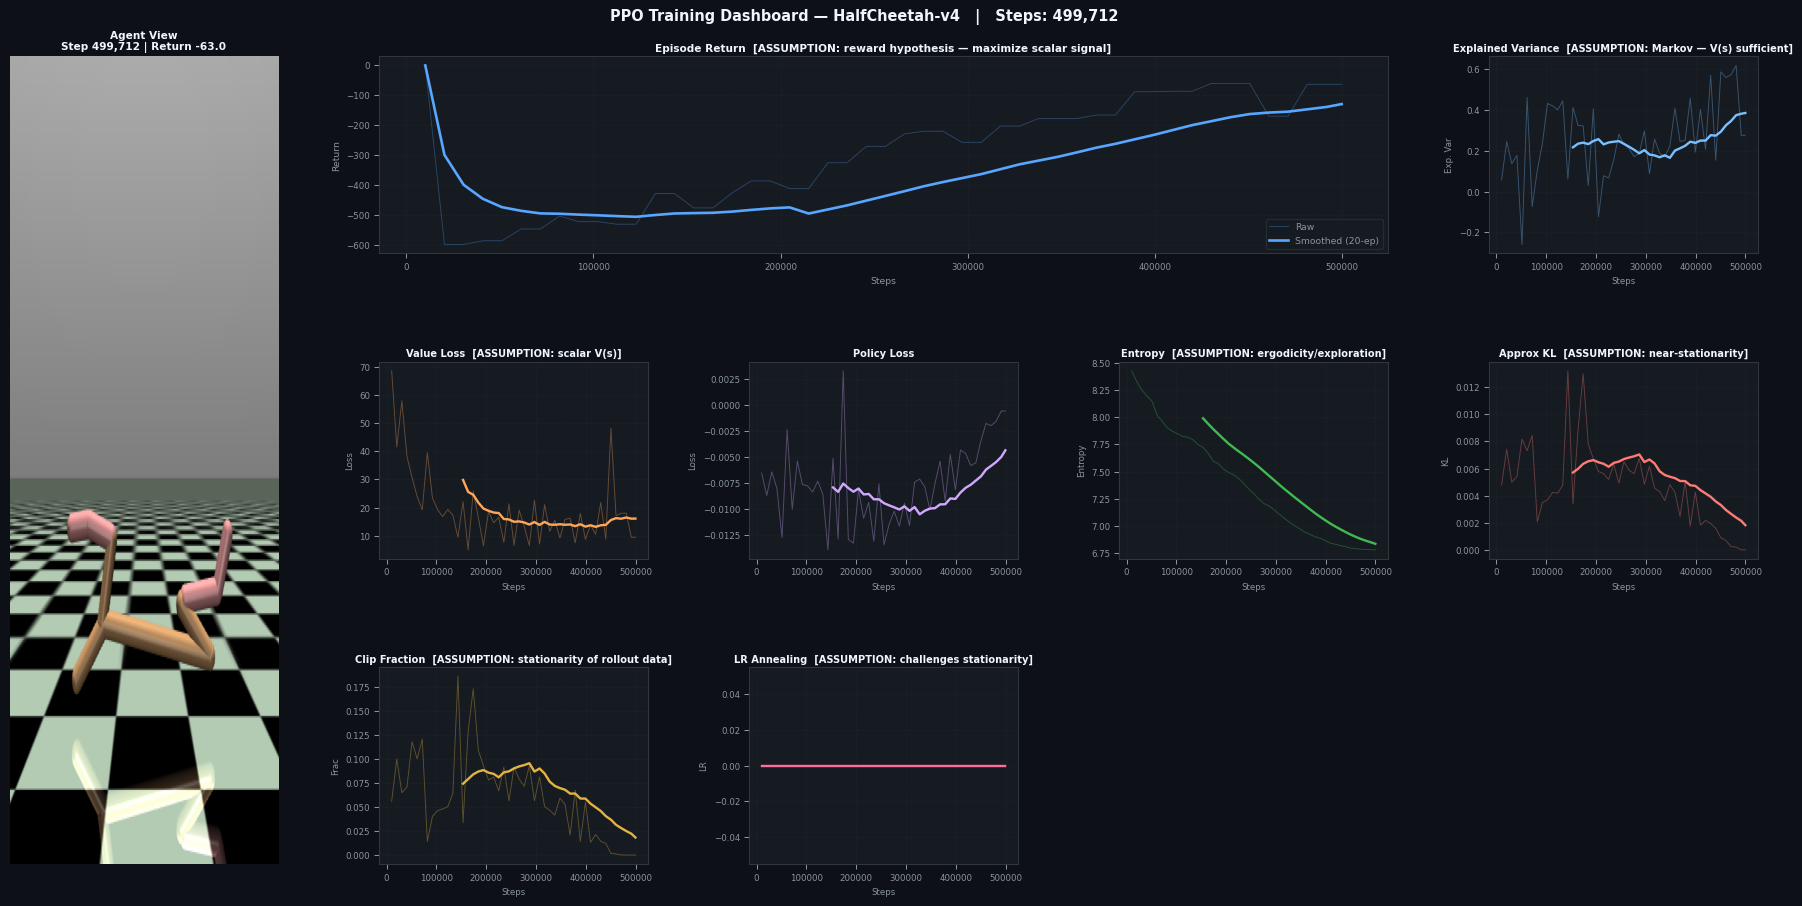


Training complete!


In [1]:
import os
os.environ["MUJOCO_GL"] = "osmesa"
os.environ["PYOPENGL_PLATFORM"] = "osmesa"
os.environ["LD_PRELOAD"] = ""   # prevents some GL lib conflicts on Colab

import subprocess, sys, os

# IN_COLAB = os.path.exists('/content')
IN_COLAB = os.path.exists('/kaggle/working')

if IN_COLAB:
    subprocess.run(["apt-get", "install", "-y", "-q", "xvfb",
                    "libgl1-mesa-glx", "libosmesa6"], capture_output=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "pyvirtualdisplay"], capture_output=True)
    subprocess.run(["apt-get", "install", "-y", "-q",
                "libosmesa6-dev", "libgl1-mesa-glx", "libglfw3"],
               capture_output=True)
    # from pyvirtualdisplay import Display
    # _vdisplay = Display(visible=False, size=(1024, 768))
    # _vdisplay.start()
    # os.environ["DISPLAY"] = ":0"
    print("✓ Virtual display started")

import subprocess, sys

def pip(pkg):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg])

pip("gymnasium")
pip("gymnasium[mujoco]")
pip("torch")
pip("numpy")
pip("matplotlib")
pip("pillow")

# Colab needs a virtual display for rgb_array MuJoCo rendering
import os
# IN_COLAB = 'google.colab' in sys.modules or os.path.exists('/content')
IN_COLAB = 'google.colab' in sys.modules or os.path.exists('/kaggle/working')
if IN_COLAB:
    subprocess.run(["apt-get", "install", "-y", "-q", "xvfb"], capture_output=True)
    pip("pyvirtualdisplay")
    try:
        from pyvirtualdisplay import Display
        _vdisplay = Display(visible=False, size=(400, 300))
        _vdisplay.start()
        print("✓ Virtual display started (Colab)")
    except Exception as e:
        print(f"⚠ Virtual display failed: {e}")

import time
import random
import io
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions.normal import Normal
from torch.distributions.categorical import Categorical

import matplotlib
matplotlib.use('Agg')   # Non-interactive — essential for Kaggle/Colab
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
from collections import deque

from IPython.display import display, clear_output
from PIL import Image

# Detect environment
try:
    import gymnasium as gym
    _e = gym.make("HalfCheetah-v4", render_mode="rgb_array")
    _e.close()
    ENV_ID       = "HalfCheetah-v4"
    IS_CONTINUOUS = True
    print("✓ MuJoCo found — using HalfCheetah-v4")
except Exception:
    import gymnasium as gym
    ENV_ID        = "CartPole-v1"
    IS_CONTINUOUS = False
    print("ℹ MuJoCo not available — using CartPole-v1")

# Hyperparams
SEED           = 42
TOTAL_TIMESTEPS = 500_000 if IS_CONTINUOUS else 150_000
NUM_ENVS       = 4      # parallel envs [ASSUMPTION: single-agent, stationary copies]
NUM_STEPS      = 512    # rollout steps  [ASSUMPTION: episodic / finite horizon]
MINIBATCH_SIZE = 256
UPDATE_EPOCHS  = 4
GAMMA          = 0.99   # [ASSUMPTION: geometric discount — finite effective horizon]
GAE_LAMBDA     = 0.95   # bias-variance tradeoff in advantage estimation
CLIP_COEF      = 0.2    # PPO trust-region proxy [ASSUMPTION: near-stationarity]
ENT_COEF       = 0.01   # [ASSUMPTION: ergodicity — entropy keeps exploration alive]
VF_COEF        = 0.5
MAX_GRAD_NORM  = 0.5
LR             = 3e-4
ANNEAL_LR      = True   # [ASSUMPTION: mild non-stationarity introduced by lr decay]
PLOT_EVERY     = 5      # redraw dashboard every N updates
RENDER_EVERY   = 10     # capture a new env frame every N updates

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# NNs
def layer_init(layer, std=np.sqrt(2), bias_const=0.0):
    nn.init.orthogonal_(layer.weight, std)
    nn.init.constant_(layer.bias, bias_const)
    return layer


class AgentContinuous(nn.Module):
    """
    [ASSUMPTION: Full observability — raw state vector fed in directly, no belief state]
    [ASSUMPTION: Markov property — only current obs used, zero history]
    [ASSUMPTION: Scalar reward — single value head V(s)]
    [ASSUMPTION: Known fixed action space — act_dim set at init and never changes]
    """
    def __init__(self, obs_dim, act_dim):
        super().__init__()
        self.critic = nn.Sequential(
            layer_init(nn.Linear(obs_dim, 256)), nn.Tanh(),
            layer_init(nn.Linear(256, 256)),     nn.Tanh(),
            layer_init(nn.Linear(256, 1), std=1.0),
        )
        self.actor_mean = nn.Sequential(
            layer_init(nn.Linear(obs_dim, 256)), nn.Tanh(),
            layer_init(nn.Linear(256, 256)),     nn.Tanh(),
            layer_init(nn.Linear(256, act_dim), std=0.01),
        )
        self.actor_log_std = nn.Parameter(torch.zeros(1, act_dim))

    def get_value(self, x):
        return self.critic(x)

    def get_action_and_value(self, x, action=None):
        mean     = self.actor_mean(x)
        std      = torch.exp(self.actor_log_std.expand_as(mean))
        dist     = Normal(mean, std)
        if action is None:
            action = dist.sample()
        return action, dist.log_prob(action).sum(1), dist.entropy().sum(1), self.critic(x)


class AgentDiscrete(nn.Module):
    # Discrete action version for CartPole
    def __init__(self, obs_dim, act_dim):
        super().__init__()
        self.net    = nn.Sequential(
            layer_init(nn.Linear(obs_dim, 64)), nn.Tanh(),
            layer_init(nn.Linear(64, 64)),      nn.Tanh(),
        )
        self.actor  = layer_init(nn.Linear(64, act_dim), std=0.01)
        self.critic = layer_init(nn.Linear(64, 1),       std=1.0)

    def get_value(self, x):
        return self.critic(self.net(x))

    def get_action_and_value(self, x, action=None):
        h    = self.net(x)
        dist = Categorical(logits=self.actor(h))
        if action is None:
            action = dist.sample()
        return action, dist.log_prob(action), dist.entropy(), self.critic(h)


# Live Dashboard (Notebook-compatible)
class LivePlotter:
    """
    Renders a combined figure:
      • Left panel  — live env frame (rgb_array)
      • Right panels — 7 training metric plots

    Uses clear_output + IPython display to simulate real-time updates.
    """

    BG      = '#0d1117'
    PANEL   = '#161b22'
    BORDER  = '#30363d'
    GRID    = '#21262d'
    TEXT    = '#f0f6fc'
    MUTED   = '#8b949e'
    BLUE    = '#58a6ff'
    ORANGE  = '#ffa657'
    PURPLE  = '#d2a8ff'
    GREEN   = '#3fb950'
    RED     = '#ff7b72'
    YELLOW  = '#e3b341'
    CYAN    = '#79c0ff'

    def __init__(self):
        self._init_data()
        self.last_frame = None

    def _init_data(self):
        self.steps      = []
        self.returns    = []
        self.ret_smooth = []
        self.v_losses   = []
        self.p_losses   = []
        self.entropies  = []
        self.kls        = []
        self.clipfracs  = []
        self.expvars    = []
        self.recent_ret = deque(maxlen=20)

    def _make_fig(self):
        fig = plt.figure(figsize=(20, 10), facecolor=self.BG)
        gs  = gridspec.GridSpec(
            3, 5,
            figure=fig,
            hspace=0.55, wspace=0.38,
            left=0.05, right=0.97,
            top=0.93,  bottom=0.08,
        )

        # Env frame panel (spans full left column)
        ax_frame = fig.add_subplot(gs[:, 0])
        ax_frame.set_facecolor('#000000')
        ax_frame.axis('off')

        # Stat panels
        ax_ret  = fig.add_subplot(gs[0, 1:4])   # wide return chart
        ax_ev   = fig.add_subplot(gs[0, 4])
        ax_vl   = fig.add_subplot(gs[1, 1])
        ax_pl   = fig.add_subplot(gs[1, 2])
        ax_ent  = fig.add_subplot(gs[1, 3])
        ax_kl   = fig.add_subplot(gs[1, 4])
        ax_cf   = fig.add_subplot(gs[2, 1])
        ax_lr   = fig.add_subplot(gs[2, 2])

        axes = [ax_frame, ax_ret, ax_ev, ax_vl, ax_pl, ax_ent, ax_kl, ax_cf, ax_lr]
        for ax in axes[1:]:
            ax.set_facecolor(self.PANEL)
            ax.grid(True, color=self.GRID, linewidth=0.5, linestyle='--', alpha=0.7)
            for spine in ax.spines.values():
                spine.set_color(self.BORDER)
            ax.tick_params(colors=self.MUTED, labelsize=6.5)

        return fig, ax_frame, ax_ret, ax_ev, ax_vl, ax_pl, ax_ent, ax_kl, ax_cf, ax_lr

    def _smooth(self, y, w=15):
        if len(y) < w:
            return y
        return np.convolve(y, np.ones(w) / w, mode='valid')

    def _plot_metric(self, ax, y, color, title, ylabel=''):
        ax.cla()
        ax.set_facecolor(self.PANEL)
        ax.grid(True, color=self.GRID, linewidth=0.5, linestyle='--', alpha=0.7)
        for spine in ax.spines.values():
            spine.set_color(self.BORDER)
        ax.tick_params(colors=self.MUTED, labelsize=6.5)

        s = self.steps
        ax.plot(s, y, color=color, linewidth=0.7, alpha=0.35)
        sm = self._smooth(y)
        if len(sm) > 0:
            ax.plot(s[max(0, len(s)-len(sm)):], sm, color=color, linewidth=1.8)

        ax.set_title(title, color=self.TEXT, fontsize=7.5, fontweight='bold', pad=4)
        ax.set_ylabel(ylabel, color=self.MUTED, fontsize=6.5)
        ax.set_xlabel('Steps', color=self.MUTED, fontsize=6.5)

    def update(self, step, ep_return, v_loss, p_loss,
               entropy, kl, clipfrac, expvar, lr, frame=None):

        # Accumulate data
        self.steps.append(step)
        self.returns.append(ep_return)
        self.recent_ret.append(ep_return)
        self.ret_smooth.append(float(np.mean(self.recent_ret)))
        self.v_losses.append(v_loss)
        self.p_losses.append(p_loss)
        self.entropies.append(entropy)
        self.kls.append(kl)
        self.clipfracs.append(clipfrac)
        self.expvars.append(expvar)

        if frame is not None:
            self.last_frame = frame

        fig, ax_frame, ax_ret, ax_ev, ax_vl, ax_pl, ax_ent, ax_kl, ax_cf, ax_lr = self._make_fig()
        s = self.steps

        # Env frame
        ax_frame.cla()
        ax_frame.set_facecolor('#000000')
        ax_frame.axis('off')
        if self.last_frame is not None:
            ax_frame.imshow(self.last_frame, aspect='auto')
        else:
            ax_frame.text(0.5, 0.5, 'Waiting\nfor frame…',
                          ha='center', va='center',
                          color=self.MUTED, fontsize=11,
                          transform=ax_frame.transAxes)
        ax_frame.set_title(
            f'Agent View\nStep {step:,} | Return {ep_return:.1f}',
            color=self.TEXT, fontsize=8, fontweight='bold', pad=5
        )

        # Return (wide panel)
        ax_ret.cla()
        ax_ret.set_facecolor(self.PANEL)
        ax_ret.grid(True, color=self.GRID, linewidth=0.5, linestyle='--', alpha=0.7)
        for spine in ax_ret.spines.values(): spine.set_color(self.BORDER)
        ax_ret.tick_params(colors=self.MUTED, labelsize=6.5)
        ax_ret.plot(s, self.returns,    color=self.BLUE, linewidth=0.7, alpha=0.3, label='Raw')
        ax_ret.plot(s, self.ret_smooth, color=self.BLUE, linewidth=2.0,            label='Smoothed (20-ep)')
        ax_ret.set_title(
            'Episode Return  [ASSUMPTION: reward hypothesis — maximize scalar signal]',
            color=self.TEXT, fontsize=8, fontweight='bold', pad=4
        )
        ax_ret.set_ylabel('Return', color=self.MUTED, fontsize=7)
        ax_ret.set_xlabel('Steps',  color=self.MUTED, fontsize=7)
        ax_ret.legend(fontsize=7, facecolor=self.PANEL, labelcolor=self.MUTED,
                      framealpha=0.6, edgecolor=self.BORDER)

        # Other metrics
        self._plot_metric(ax_ev,  self.expvars,   self.CYAN,
            'Explained Variance  [ASSUMPTION: Markov — V(s) sufficient]', 'Exp. Var')
        self._plot_metric(ax_vl,  self.v_losses,  self.ORANGE,
            'Value Loss  [ASSUMPTION: scalar V(s)]', 'Loss')
        self._plot_metric(ax_pl,  self.p_losses,  self.PURPLE,
            'Policy Loss', 'Loss')
        self._plot_metric(ax_ent, self.entropies, self.GREEN,
            'Entropy  [ASSUMPTION: ergodicity/exploration]', 'Entropy')
        self._plot_metric(ax_kl,  self.kls,       self.RED,
            'Approx KL  [ASSUMPTION: near-stationarity]', 'KL')
        self._plot_metric(ax_cf,  self.clipfracs, self.YELLOW,
            'Clip Fraction  [ASSUMPTION: stationarity of rollout data]', 'Frac')

        # LR panel (shows annealing)
        ax_lr.cla()
        ax_lr.set_facecolor(self.PANEL)
        ax_lr.grid(True, color=self.GRID, linewidth=0.5, linestyle='--', alpha=0.7)
        for spine in ax_lr.spines.values(): spine.set_color(self.BORDER)
        ax_lr.tick_params(colors=self.MUTED, labelsize=6.5)
        # Reconstruct lr curve from steps (proxy)
        max_step = max(self.steps) if self.steps else 1
        lr_curve = [lr * (1 - st / max_step) for st in self.steps]
        ax_lr.plot(s, lr_curve, color='#ff6e96', linewidth=1.8)
        ax_lr.set_title('LR Annealing  [ASSUMPTION: challenges stationarity]',
                        color=self.TEXT, fontsize=7.5, fontweight='bold', pad=4)
        ax_lr.set_ylabel('LR', color=self.MUTED, fontsize=6.5)
        ax_lr.set_xlabel('Steps', color=self.MUTED, fontsize=6.5)

        # Main title
        fig.suptitle(
            f'PPO Training Dashboard — {ENV_ID}   |   Steps: {step:,}',
            color=self.TEXT, fontsize=11, fontweight='bold', y=0.98
        )

        # Render to bytes and display inline
        buf = io.BytesIO()
        fig.savefig(buf, format='png', dpi=95,
                    bbox_inches='tight', facecolor=self.BG)
        buf.seek(0)
        plt.close(fig)

        clear_output(wait=True)
        display(Image.open(buf))


# Environment helpers
def make_env(env_id, seed, idx):
    def thunk():
        e = gym.make(env_id)
        e = gym.wrappers.RecordEpisodeStatistics(e)
        e.reset(seed=seed + idx)
        return e
    return thunk


# Training loop
def train():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device : {device}")
    print(f"Env    : {ENV_ID}")
    print(f"Steps  : {TOTAL_TIMESTEPS:,}")

    # Vectorised training envs
    # [ASSUMPTION: single-agent — each env is an independent copy, no inter-agent dynamics]
    envs = gym.vector.SyncVectorEnv(
        [make_env(ENV_ID, SEED, i) for i in range(NUM_ENVS)]
    )
    obs_dim = int(np.prod(envs.single_observation_space.shape))
    act_dim = (int(np.prod(envs.single_action_space.shape))
               if IS_CONTINUOUS else envs.single_action_space.n)

    # Agent
    Agent = AgentContinuous if IS_CONTINUOUS else AgentDiscrete
    agent = Agent(obs_dim, act_dim).to(device)
    optimizer = optim.Adam(agent.parameters(), lr=LR, eps=1e-5)

    # Render env (rgb_array — no GUI needed)
    render_env = gym.make(ENV_ID, render_mode="rgb_array")
    render_obs, _ = render_env.reset(seed=SEED + 99)

    # Rollout buffers
    # [ASSUMPTION: episodic/finite horizon — fixed NUM_STEPS per rollout]
    act_shape  = (act_dim,) if IS_CONTINUOUS else ()
    obs_buf    = torch.zeros(NUM_STEPS, NUM_ENVS, obs_dim).to(device)
    act_buf    = torch.zeros(NUM_STEPS, NUM_ENVS, *act_shape).to(device)
    logp_buf   = torch.zeros(NUM_STEPS, NUM_ENVS).to(device)
    rew_buf    = torch.zeros(NUM_STEPS, NUM_ENVS).to(device)
    done_buf   = torch.zeros(NUM_STEPS, NUM_ENVS).to(device)
    val_buf    = torch.zeros(NUM_STEPS, NUM_ENVS).to(device)

    plotter     = LivePlotter()
    global_step = 0
    num_updates = TOTAL_TIMESTEPS // (NUM_ENVS * NUM_STEPS)
    start_time  = time.time()

    obs, _  = envs.reset(seed=SEED)
    obs     = torch.tensor(obs, dtype=torch.float32).to(device)
    done    = torch.zeros(NUM_ENVS).to(device)
    current_frame = None

    print(f"\nStarting: {num_updates} updates × {NUM_STEPS} steps × {NUM_ENVS} envs\n" + "─"*60)

    for update in range(1, num_updates + 1):

        # LR annealing
        # [ASSUMPTION: introduces mild non-stationarity — lr shrinks linearly]
        if ANNEAL_LR:
            frac = 1.0 - (update - 1.0) / num_updates
            current_lr = frac * LR
            optimizer.param_groups[0]["lr"] = current_lr
        else:
            current_lr = LR

        # # Capture a render frame
        # if update % RENDER_EVERY == 0 or update == 1:
        #     try:
        #         r_obs, _ = render_env.reset()
        #         r_done   = False
        #         for _ in range(200):
        #             with torch.no_grad():
        #                 t = torch.tensor(r_obs, dtype=torch.float32).unsqueeze(0).to(device)
        #                 a, _, _, _ = agent.get_action_and_value(t)
        #             r_obs, _, rt, ru, _ = render_env.step(
        #                 a.cpu().numpy().squeeze() if IS_CONTINUOUS else int(a.item())
        #             )
        #             r_done = rt or ru
        #             if r_done:
        #                 break
        #         current_frame = render_env.render()   # rgb_array
        #     except Exception:
        #         pass

        if update % RENDER_EVERY == 0 or update == 1:
            try:
                r_obs, _ = render_env.reset()
                r_done = False
                latest_frame = None
                for _ in range(500):
                    with torch.no_grad():
                        t = torch.tensor(r_obs, dtype=torch.float32).unsqueeze(0).to(device)
                        a, _, _, _ = agent.get_action_and_value(t)
                    r_obs, _, rt, ru, _ = render_env.step(
                        a.cpu().numpy().squeeze() if IS_CONTINUOUS else int(a.item())
                    )
                    latest_frame = render_env.render()   # capture INSIDE the loop
                    r_done = rt or ru
                    if r_done:
                        break
                if latest_frame is not None:
                    current_frame = latest_frame          # only update if we got something
            except Exception as e:
                print(f"Render warning: {e}")

        # Collect rollout
        # [ASSUMPTION: Markov — only obs[t] fed in, no history]
        # [ASSUMPTION: full observability — raw state vector used directly]
        ep_returns = []
        for step in range(NUM_STEPS):
            global_step += NUM_ENVS
            obs_buf[step]  = obs
            done_buf[step] = done

            with torch.no_grad():
                action, logp, _, value = agent.get_action_and_value(obs)
                val_buf[step] = value.flatten()

            act_buf[step]  = action
            logp_buf[step] = logp

            obs_np, rew, term, trunc, info = envs.step(action.cpu().numpy())

            # [ASSUMPTION: scalar reward — single float per env per step]
            rew_buf[step] = torch.tensor(rew, dtype=torch.float32).to(device)
            done = torch.tensor(
                np.logical_or(term, trunc), dtype=torch.float32
            ).to(device)
            obs  = torch.tensor(obs_np, dtype=torch.float32).to(device)

            # if "final_info" in info:
            #     for fi in info["final_info"]:
            #         if fi is not None and "episode" in fi:
            #             ep_returns.append(float(fi["episode"]["r"]))
            # if "final_info" in info:
            #     for fi in info["final_info"]:
            #         if fi is not None and "episode" in fi:
            #             ep_returns.append(float(fi["episode"]["r"]))
            # elif "_episode" in info:
            #     # older gymnasium vectorenv format
            #     for i, has_ep in enumerate(info["_episode"]):
            #         if has_ep:
            #             ep_returns.append(float(info["episode"]["r"][i]))
            if "_episode" in info:
                for i, finished in enumerate(info["_episode"]):
                    if finished:
                        ep_returns.append(float(info["episode"]["r"][i]))

        # GAE Advantage Estimation
        # [ASSUMPTION: Markov — bootstrap V(s_{t+1}) depends only on next state]
        # [ASSUMPTION: geometric discount γ — exponentially shrinks future rewards]
        # [ASSUMPTION: stationarity — V(s) treated as fixed during bootstrapping]
        with torch.no_grad():
            next_val   = agent.get_value(obs).reshape(1, -1)
            advantages = torch.zeros_like(rew_buf).to(device)
            gae        = 0.0
            for t in reversed(range(NUM_STEPS)):
                nnt = 1.0 - (done if t == NUM_STEPS - 1 else done_buf[t + 1])
                nv  = next_val if t == NUM_STEPS - 1 else val_buf[t + 1]
                delta = rew_buf[t] + GAMMA * nv * nnt - val_buf[t]
                gae   = delta + GAMMA * GAE_LAMBDA * nnt * gae
                advantages[t] = gae
            returns = advantages + val_buf

        # PPO Minibatch Updates
        # [ASSUMPTION: reward hypothesis — single scalar loss drives policy]
        # [ASSUMPTION: single agent — gradient from one policy only]
        b_obs  = obs_buf.reshape(-1, obs_dim)
        b_act  = act_buf.reshape(-1, *act_buf.shape[2:])
        b_logp = logp_buf.reshape(-1)
        b_adv  = advantages.reshape(-1)
        b_ret  = returns.reshape(-1)
        b_val  = val_buf.reshape(-1)

        cf_list, vl_list, pl_list, ent_list, kl_list = [], [], [], [], []

        for _ in range(UPDATE_EPOCHS):
            idx = np.random.permutation(NUM_STEPS * NUM_ENVS)
            for start in range(0, NUM_STEPS * NUM_ENVS, MINIBATCH_SIZE):
                mb    = idx[start:start + MINIBATCH_SIZE]
                mb_o  = b_obs[mb]
                mb_a  = b_act[mb]
                mb_lp = b_logp[mb]
                mb_ad = b_adv[mb]
                mb_r  = b_ret[mb]
                mb_v  = b_val[mb]

                _, nlp, ent, nv = agent.get_action_and_value(
                    mb_o, mb_a if IS_CONTINUOUS else mb_a.long()
                )
                nv = nv.flatten()
                log_ratio  = nlp - mb_lp
                ratio      = log_ratio.exp()

                with torch.no_grad():
                    kl = ((ratio - 1) - log_ratio).mean()
                    cf_list.append(((ratio - 1.0).abs() > CLIP_COEF).float().mean().item())

                # Normalise advantages within minibatch
                # [ASSUMPTION: local stationarity — mean/std of batch treated as stable]
                mb_ad = (mb_ad - mb_ad.mean()) / (mb_ad.std() + 1e-8)

                # Clipped policy loss
                pg1 = -mb_ad * ratio
                pg2 = -mb_ad * torch.clamp(ratio, 1 - CLIP_COEF, 1 + CLIP_COEF)
                pl  = torch.max(pg1, pg2).mean()

                # Clipped value loss
                # [ASSUMPTION: scalar V(s) — one number per state]
                v_unclip = (nv - mb_r) ** 2
                v_clip   = mb_v + torch.clamp(nv - mb_v, -CLIP_COEF, CLIP_COEF)
                vl       = 0.5 * torch.max(v_unclip, (v_clip - mb_r) ** 2).mean()

                # Entropy bonus
                # [ASSUMPTION: ergodicity — entropy term encourages sufficient exploration]
                el = ent.mean()

                loss = pl + VF_COEF * vl - ENT_COEF * el
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(agent.parameters(), MAX_GRAD_NORM)
                optimizer.step()

                vl_list.append(vl.item())
                pl_list.append(pl.item())
                ent_list.append(el.item())
                kl_list.append(kl.item())

        # Explained variance
        # [ASSUMPTION: Markov — high exp-var means current state is sufficient predictor]
        yp  = b_val.cpu().numpy()
        yt  = b_ret.cpu().numpy()
        vy  = np.var(yt)
        ev  = float(1 - np.var(yt - yp) / vy) if vy > 0 else 0.0

        sps         = int(global_step / (time.time() - start_time))
        mean_return = float(np.mean(ep_returns)) if ep_returns else float('nan')

        # Console log
        if update % 5 == 0 or update == 1:
            print(f"Update {update:4d}/{num_updates} | "
                  f"Steps {global_step:>9,} | "
                  f"Return {mean_return:>8.1f} | "
                  f"VLoss {np.mean(vl_list):.4f} | "
                  f"KL {np.mean(kl_list):.4f} | "
                  f"ExpVar {ev:.3f} | "
                  f"SPS {sps:>6,}")

        # # Live dashboard refresh
        # if not np.isnan(mean_return) and update % PLOT_EVERY == 0:
        #     plotter.update(
        #         step      = global_step,
        #         ep_return = mean_return,
        #         v_loss    = float(np.mean(vl_list)),
        #         p_loss    = float(np.mean(pl_list)),
        #         entropy   = float(np.mean(ent_list)),
        #         kl        = float(np.mean(kl_list)),
        #         clipfrac  = float(np.mean(cf_list)),
        #         expvar    = ev,
        #         lr        = current_lr,
        #         frame     = current_frame,
        #     )
        # if update % PLOT_EVERY == 0:
        #     safe_return = mean_return if not np.isnan(mean_return) else (
        #         plotter.returns[-1] if plotter.returns else 0.0
        #     )
        #     plotter.update(
        #         step      = global_step,
        #         ep_return = mean_return,
        #         v_loss    = float(np.mean(vl_list)),
        #         p_loss    = float(np.mean(pl_list)),
        #         entropy   = float(np.mean(ent_list)),
        #         kl        = float(np.mean(kl_list)),
        #         clipfrac  = float(np.mean(cf_list)),
        #         expvar    = ev,
        #         lr        = current_lr,
        #         frame     = current_frame,
        #     )

        if update % PLOT_EVERY == 0:
            safe_return = float(np.mean(ep_returns)) if ep_returns else (
                plotter.returns[-1] if plotter.returns else 0.0
            )
            plotter.update(
                step      = global_step,
                ep_return = safe_return,
                v_loss    = float(np.mean(vl_list)),
                p_loss    = float(np.mean(pl_list)),
                entropy   = float(np.mean(ent_list)),
                kl        = float(np.mean(kl_list)),
                clipfrac  = float(np.mean(cf_list)),
                expvar    = ev,
                lr        = current_lr,
                frame     = current_frame,
            )

    envs.close()
    render_env.close()

    # Final dashboard flush
    if plotter.steps:
        plotter.update(
            step      = global_step,
            ep_return = plotter.returns[-1],
            v_loss    = plotter.v_losses[-1],
            p_loss    = plotter.p_losses[-1],
            entropy   = plotter.entropies[-1],
            kl        = plotter.kls[-1],
            clipfrac  = plotter.clipfracs[-1],
            expvar    = plotter.expvars[-1],
            lr        = 0.0,
            frame     = current_frame,
        )

    print("\n" + "="*60)
    print("Training complete!")


# Run
train()

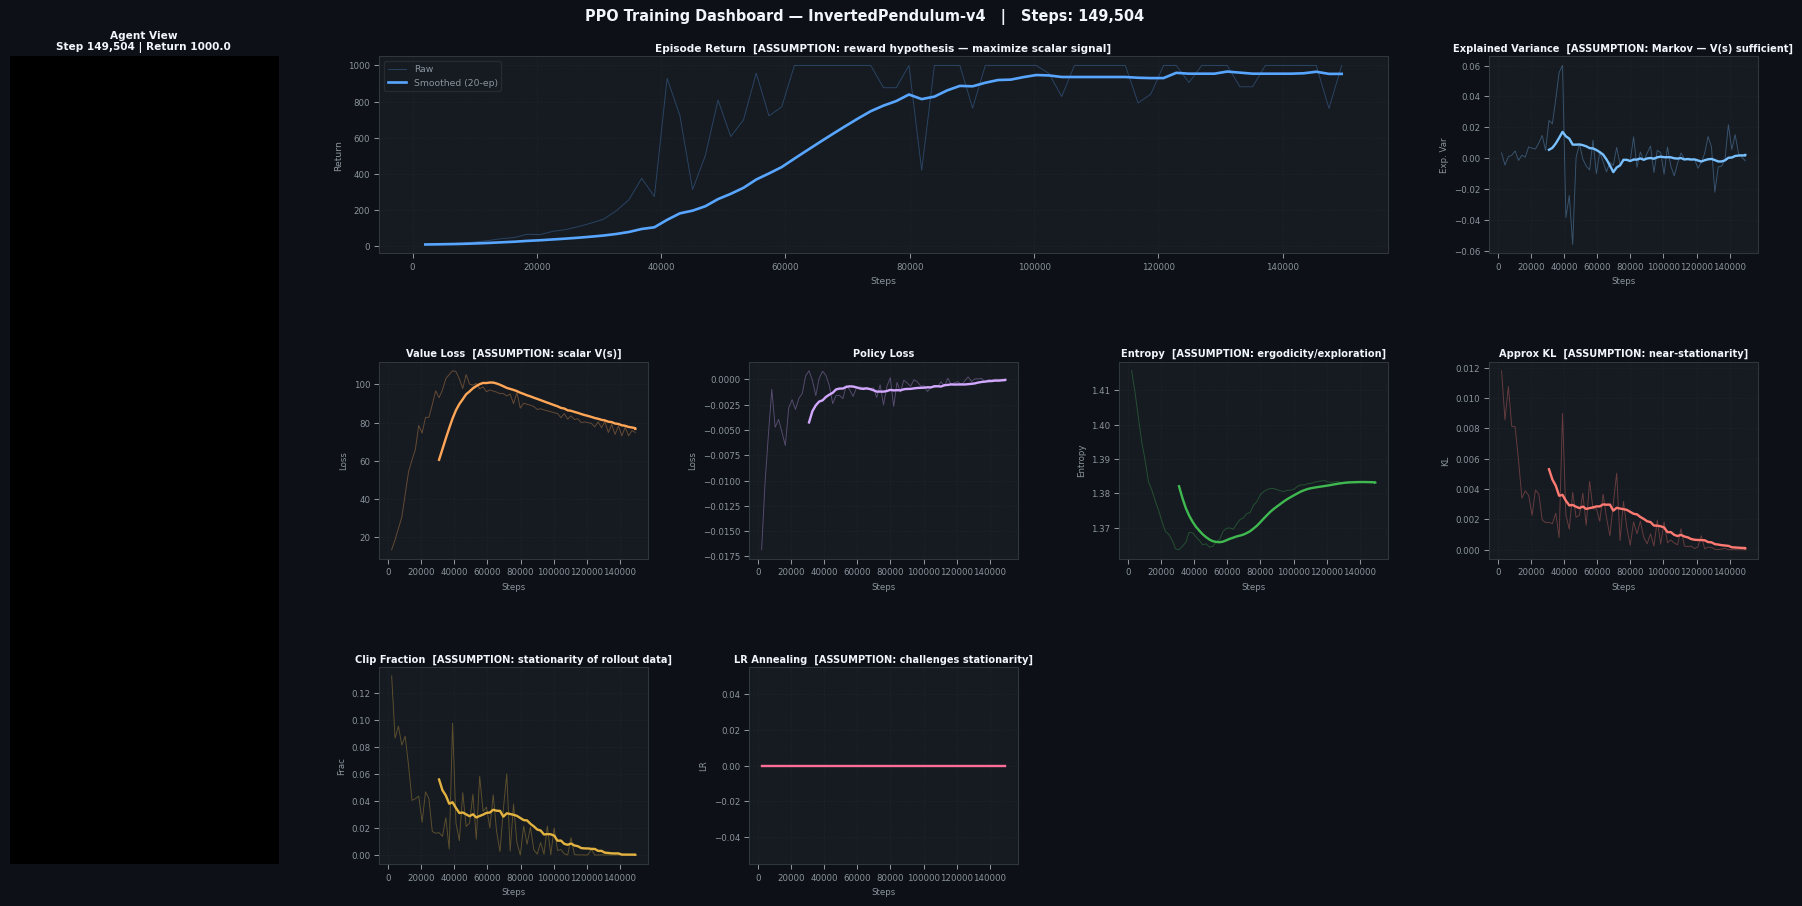


Training complete!


In [8]:
import os
os.environ["MUJOCO_GL"] = "osmesa"
os.environ["PYOPENGL_PLATFORM"] = "osmesa"
os.environ["LD_PRELOAD"] = ""   # prevents some GL lib conflicts on Colab

import subprocess, sys, os

# IN_COLAB = os.path.exists('/content')
IN_COLAB = os.path.exists('/kaggle/working')

if IN_COLAB:
    subprocess.run(["apt-get", "install", "-y", "-q", "xvfb",
                    "libgl1-mesa-glx", "libosmesa6"], capture_output=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "pyvirtualdisplay"], capture_output=True)
    subprocess.run(["apt-get", "install", "-y", "-q",
                "libosmesa6-dev", "libgl1-mesa-glx", "libglfw3"],
               capture_output=True)
    print("✓ Virtual display started")

import subprocess, sys

def pip(pkg):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg])

pip("gymnasium")
pip("gymnasium[mujoco]")
pip("torch")
pip("numpy")
pip("matplotlib")
pip("pillow")

# Colab needs a virtual display for rgb_array MuJoCo rendering
import os
IN_COLAB = 'google.colab' in sys.modules or os.path.exists('/kaggle/working')
if IN_COLAB:
    subprocess.run(["apt-get", "install", "-y", "-q", "xvfb"], capture_output=True)
    pip("pyvirtualdisplay")
    try:
        from pyvirtualdisplay import Display
        _vdisplay = Display(visible=False, size=(400, 300))
        _vdisplay.start()
        print("✓ Virtual display started (Colab)")
    except Exception as e:
        print(f"⚠ Virtual display failed: {e}")

import time
import random
import io
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions.normal import Normal
from torch.distributions.categorical import Categorical

import matplotlib
matplotlib.use('Agg')   # Non-interactive — essential for Kaggle/Colab
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
from collections import deque

from IPython.display import display, clear_output
from PIL import Image

# Detect environment
# Trying InvertedPendulum-v4 instead of HalfCheetah-v4
try:
    import gymnasium as gym
    _e = gym.make("InvertedPendulum-v4", render_mode="rgb_array")
    _e.close()
    ENV_ID        = "InvertedPendulum-v4"
    IS_CONTINUOUS = True
    print("✓ MuJoCo found — using InvertedPendulum-v4")
except Exception:
    import gymnasium as gym
    ENV_ID        = "CartPole-v1"
    IS_CONTINUOUS = False
    print("ℹ MuJoCo not available — using CartPole-v1")

# Hyperparams
SEED           = 42
# 150k steps is plenty for InvertedPendulum (vs 500k for HalfCheetah)
TOTAL_TIMESTEPS = 150_000 if IS_CONTINUOUS else 150_000
NUM_ENVS       = 4      # parallel envs [ASSUMPTION: single-agent, stationary copies]
NUM_STEPS      = 512    # rollout steps  [ASSUMPTION: episodic / finite horizon]
MINIBATCH_SIZE = 256
UPDATE_EPOCHS  = 4
GAMMA          = 0.99   # [ASSUMPTION: geometric discount — finite effective horizon]
GAE_LAMBDA     = 0.95   # bias-variance tradeoff in advantage estimation
CLIP_COEF      = 0.2    # PPO trust-region proxy [ASSUMPTION: near-stationarity]
ENT_COEF       = 0.01   # [ASSUMPTION: ergodicity — entropy keeps exploration alive]
VF_COEF        = 0.5
MAX_GRAD_NORM  = 0.5
LR             = 3e-4
ANNEAL_LR      = True   # [ASSUMPTION: mild non-stationarity introduced by lr decay]
PLOT_EVERY     = 1      # redraw dashboard every N updates
RENDER_EVERY   = 10     # capture a new env frame every N updates

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# NNs
def layer_init(layer, std=np.sqrt(2), bias_const=0.0):
    nn.init.orthogonal_(layer.weight, std)
    nn.init.constant_(layer.bias, bias_const)
    return layer


class AgentContinuous(nn.Module):
    """
    [ASSUMPTION: Full observability — raw state vector fed in directly, no belief state]
    [ASSUMPTION: Markov property — only current obs used, zero history]
    [ASSUMPTION: Scalar reward — single value head V(s)]
    [ASSUMPTION: Known fixed action space — act_dim set at init and never changes]
    """
    def __init__(self, obs_dim, act_dim):
        super().__init__()
        self.critic = nn.Sequential(
            layer_init(nn.Linear(obs_dim, 256)), nn.Tanh(),
            layer_init(nn.Linear(256, 256)),     nn.Tanh(),
            layer_init(nn.Linear(256, 1), std=1.0),
        )
        self.actor_mean = nn.Sequential(
            layer_init(nn.Linear(obs_dim, 256)), nn.Tanh(),
            layer_init(nn.Linear(256, 256)),     nn.Tanh(),
            layer_init(nn.Linear(256, act_dim), std=0.01),
        )
        self.actor_log_std = nn.Parameter(torch.zeros(1, act_dim))

    def get_value(self, x):
        return self.critic(x)

    def get_action_and_value(self, x, action=None):
        mean     = self.actor_mean(x)
        std      = torch.exp(self.actor_log_std.expand_as(mean))
        dist     = Normal(mean, std)
        if action is None:
            action = dist.sample()
        return action, dist.log_prob(action).sum(1), dist.entropy().sum(1), self.critic(x)


class AgentDiscrete(nn.Module):
    # Discrete action version for CartPole
    def __init__(self, obs_dim, act_dim):
        super().__init__()
        self.net    = nn.Sequential(
            layer_init(nn.Linear(obs_dim, 64)), nn.Tanh(),
            layer_init(nn.Linear(64, 64)),      nn.Tanh(),
        )
        self.actor  = layer_init(nn.Linear(64, act_dim), std=0.01)
        self.critic = layer_init(nn.Linear(64, 1),       std=1.0)

    def get_value(self, x):
        return self.critic(self.net(x))

    def get_action_and_value(self, x, action=None):
        h    = self.net(x)
        dist = Categorical(logits=self.actor(h))
        if action is None:
            action = dist.sample()
        return action, dist.log_prob(action), dist.entropy(), self.critic(h)


# Live Dashboard (Notebook-compatible)
class LivePlotter:
    """
    Renders a combined figure:
      • Left panel  — live env frame (rgb_array)
      • Right panels — 7 training metric plots

    Uses clear_output + IPython display to simulate real-time updates.
    """

    BG      = '#0d1117'
    PANEL   = '#161b22'
    BORDER  = '#30363d'
    GRID    = '#21262d'
    TEXT    = '#f0f6fc'
    MUTED   = '#8b949e'
    BLUE    = '#58a6ff'
    ORANGE  = '#ffa657'
    PURPLE  = '#d2a8ff'
    GREEN   = '#3fb950'
    RED     = '#ff7b72'
    YELLOW  = '#e3b341'
    CYAN    = '#79c0ff'

    def __init__(self):
        self._init_data()
        self.last_frame = None

    def _init_data(self):
        self.steps      = []
        self.returns    = []
        self.ret_smooth = []
        self.v_losses   = []
        self.p_losses   = []
        self.entropies  = []
        self.kls        = []
        self.clipfracs  = []
        self.expvars    = []
        self.recent_ret = deque(maxlen=20)

    def _make_fig(self):
        fig = plt.figure(figsize=(20, 10), facecolor=self.BG)
        gs  = gridspec.GridSpec(
            3, 5,
            figure=fig,
            hspace=0.55, wspace=0.38,
            left=0.05, right=0.97,
            top=0.93,  bottom=0.08,
        )

        # Env frame panel (spans full left column)
        ax_frame = fig.add_subplot(gs[:, 0])
        ax_frame.set_facecolor('#000000')
        ax_frame.axis('off')

        # Stat panels
        ax_ret  = fig.add_subplot(gs[0, 1:4])   # wide return chart
        ax_ev   = fig.add_subplot(gs[0, 4])
        ax_vl   = fig.add_subplot(gs[1, 1])
        ax_pl   = fig.add_subplot(gs[1, 2])
        ax_ent  = fig.add_subplot(gs[1, 3])
        ax_kl   = fig.add_subplot(gs[1, 4])
        ax_cf   = fig.add_subplot(gs[2, 1])
        ax_lr   = fig.add_subplot(gs[2, 2])

        axes = [ax_frame, ax_ret, ax_ev, ax_vl, ax_pl, ax_ent, ax_kl, ax_cf, ax_lr]
        for ax in axes[1:]:
            ax.set_facecolor(self.PANEL)
            ax.grid(True, color=self.GRID, linewidth=0.5, linestyle='--', alpha=0.7)
            for spine in ax.spines.values():
                spine.set_color(self.BORDER)
            ax.tick_params(colors=self.MUTED, labelsize=6.5)

        return fig, ax_frame, ax_ret, ax_ev, ax_vl, ax_pl, ax_ent, ax_kl, ax_cf, ax_lr

    def _smooth(self, y, w=15):
        if len(y) < w:
            return y
        return np.convolve(y, np.ones(w) / w, mode='valid')

    def _plot_metric(self, ax, y, color, title, ylabel=''):
        ax.cla()
        ax.set_facecolor(self.PANEL)
        ax.grid(True, color=self.GRID, linewidth=0.5, linestyle='--', alpha=0.7)
        for spine in ax.spines.values():
            spine.set_color(self.BORDER)
        ax.tick_params(colors=self.MUTED, labelsize=6.5)

        s = self.steps
        ax.plot(s, y, color=color, linewidth=0.7, alpha=0.35)
        sm = self._smooth(y)
        if len(sm) > 0:
            ax.plot(s[max(0, len(s)-len(sm)):], sm, color=color, linewidth=1.8)

        ax.set_title(title, color=self.TEXT, fontsize=7.5, fontweight='bold', pad=4)
        ax.set_ylabel(ylabel, color=self.MUTED, fontsize=6.5)
        ax.set_xlabel('Steps', color=self.MUTED, fontsize=6.5)

    def update(self, step, ep_return, v_loss, p_loss,
               entropy, kl, clipfrac, expvar, lr, frame=None):

        # Accumulate data
        self.steps.append(step)
        self.returns.append(ep_return)
        self.recent_ret.append(ep_return)
        self.ret_smooth.append(float(np.mean(self.recent_ret)))
        self.v_losses.append(v_loss)
        self.p_losses.append(p_loss)
        self.entropies.append(entropy)
        self.kls.append(kl)
        self.clipfracs.append(clipfrac)
        self.expvars.append(expvar)

        if frame is not None:
            self.last_frame = frame

        fig, ax_frame, ax_ret, ax_ev, ax_vl, ax_pl, ax_ent, ax_kl, ax_cf, ax_lr = self._make_fig()
        s = self.steps

        # Env frame
        ax_frame.cla()
        ax_frame.set_facecolor('#000000')
        ax_frame.axis('off')
        if self.last_frame is not None:
            ax_frame.imshow(self.last_frame, aspect='auto')
        else:
            ax_frame.text(0.5, 0.5, 'Waiting\nfor frame…',
                          ha='center', va='center',
                          color=self.MUTED, fontsize=11,
                          transform=ax_frame.transAxes)
        ax_frame.set_title(
            f'Agent View\nStep {step:,} | Return {ep_return:.1f}',
            color=self.TEXT, fontsize=8, fontweight='bold', pad=5
        )

        # Return (wide panel)
        ax_ret.cla()
        ax_ret.set_facecolor(self.PANEL)
        ax_ret.grid(True, color=self.GRID, linewidth=0.5, linestyle='--', alpha=0.7)
        for spine in ax_ret.spines.values(): spine.set_color(self.BORDER)
        ax_ret.tick_params(colors=self.MUTED, labelsize=6.5)
        ax_ret.plot(s, self.returns,    color=self.BLUE, linewidth=0.7, alpha=0.3, label='Raw')
        ax_ret.plot(s, self.ret_smooth, color=self.BLUE, linewidth=2.0,            label='Smoothed (20-ep)')
        ax_ret.set_title(
            'Episode Return  [ASSUMPTION: reward hypothesis — maximize scalar signal]',
            color=self.TEXT, fontsize=8, fontweight='bold', pad=4
        )
        ax_ret.set_ylabel('Return', color=self.MUTED, fontsize=7)
        ax_ret.set_xlabel('Steps',  color=self.MUTED, fontsize=7)
        ax_ret.legend(fontsize=7, facecolor=self.PANEL, labelcolor=self.MUTED,
                      framealpha=0.6, edgecolor=self.BORDER)

        # Other metrics
        self._plot_metric(ax_ev,  self.expvars,   self.CYAN,
            'Explained Variance  [ASSUMPTION: Markov — V(s) sufficient]', 'Exp. Var')
        self._plot_metric(ax_vl,  self.v_losses,  self.ORANGE,
            'Value Loss  [ASSUMPTION: scalar V(s)]', 'Loss')
        self._plot_metric(ax_pl,  self.p_losses,  self.PURPLE,
            'Policy Loss', 'Loss')
        self._plot_metric(ax_ent, self.entropies, self.GREEN,
            'Entropy  [ASSUMPTION: ergodicity/exploration]', 'Entropy')
        self._plot_metric(ax_kl,  self.kls,       self.RED,
            'Approx KL  [ASSUMPTION: near-stationarity]', 'KL')
        self._plot_metric(ax_cf,  self.clipfracs, self.YELLOW,
            'Clip Fraction  [ASSUMPTION: stationarity of rollout data]', 'Frac')

        # LR panel (shows annealing)
        ax_lr.cla()
        ax_lr.set_facecolor(self.PANEL)
        ax_lr.grid(True, color=self.GRID, linewidth=0.5, linestyle='--', alpha=0.7)
        for spine in ax_lr.spines.values(): spine.set_color(self.BORDER)
        ax_lr.tick_params(colors=self.MUTED, labelsize=6.5)
        max_step = max(self.steps) if self.steps else 1
        lr_curve = [lr * (1 - st / max_step) for st in self.steps]
        ax_lr.plot(s, lr_curve, color='#ff6e96', linewidth=1.8)
        ax_lr.set_title('LR Annealing  [ASSUMPTION: challenges stationarity]',
                        color=self.TEXT, fontsize=7.5, fontweight='bold', pad=4)
        ax_lr.set_ylabel('LR', color=self.MUTED, fontsize=6.5)
        ax_lr.set_xlabel('Steps', color=self.MUTED, fontsize=6.5)

        # Main title
        fig.suptitle(
            f'PPO Training Dashboard — {ENV_ID}   |   Steps: {step:,}',
            color=self.TEXT, fontsize=11, fontweight='bold', y=0.98
        )

        # Render to bytes and display inline
        buf = io.BytesIO()
        fig.savefig(buf, format='png', dpi=95,
                    bbox_inches='tight', facecolor=self.BG)
        buf.seek(0)
        plt.close(fig)

        clear_output(wait=True)
        display(Image.open(buf))


# Environment helpers
def make_env(env_id, seed, idx):
    def thunk():
        e = gym.make(env_id)
        e = gym.wrappers.RecordEpisodeStatistics(e)
        e.reset(seed=seed + idx)
        return e
    return thunk


# Training loop
def train():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device : {device}")
    print(f"Env    : {ENV_ID}")
    print(f"Steps  : {TOTAL_TIMESTEPS:,}")

    # [ASSUMPTION: single-agent — each env is an independent copy, no inter-agent dynamics]
    envs = gym.vector.SyncVectorEnv(
        [make_env(ENV_ID, SEED, i) for i in range(NUM_ENVS)]
    )
    obs_dim = int(np.prod(envs.single_observation_space.shape))
    act_dim = (int(np.prod(envs.single_action_space.shape))
               if IS_CONTINUOUS else envs.single_action_space.n)

    Agent = AgentContinuous if IS_CONTINUOUS else AgentDiscrete
    agent = Agent(obs_dim, act_dim).to(device)
    optimizer = optim.Adam(agent.parameters(), lr=LR, eps=1e-5)

    # Render env (rgb_array — no GUI needed)
    render_env = gym.make(ENV_ID, render_mode="rgb_array")
    render_obs, _ = render_env.reset(seed=SEED + 99)

    # [ASSUMPTION: episodic/finite horizon — fixed NUM_STEPS per rollout]
    act_shape  = (act_dim,) if IS_CONTINUOUS else ()
    obs_buf    = torch.zeros(NUM_STEPS, NUM_ENVS, obs_dim).to(device)
    act_buf    = torch.zeros(NUM_STEPS, NUM_ENVS, *act_shape).to(device)
    logp_buf   = torch.zeros(NUM_STEPS, NUM_ENVS).to(device)
    rew_buf    = torch.zeros(NUM_STEPS, NUM_ENVS).to(device)
    done_buf   = torch.zeros(NUM_STEPS, NUM_ENVS).to(device)
    val_buf    = torch.zeros(NUM_STEPS, NUM_ENVS).to(device)

    plotter     = LivePlotter()
    global_step = 0
    num_updates = TOTAL_TIMESTEPS // (NUM_ENVS * NUM_STEPS)
    start_time  = time.time()

    obs, _  = envs.reset(seed=SEED)
    obs     = torch.tensor(obs, dtype=torch.float32).to(device)
    done    = torch.zeros(NUM_ENVS).to(device)
    current_frame = None

    print(f"\nStarting: {num_updates} updates × {NUM_STEPS} steps × {NUM_ENVS} envs\n" + "─"*60)

    for update in range(1, num_updates + 1):

        # [ASSUMPTION: introduces mild non-stationarity — lr shrinks linearly]
        if ANNEAL_LR:
            frac = 1.0 - (update - 1.0) / num_updates
            current_lr = frac * LR
            optimizer.param_groups[0]["lr"] = current_lr
        else:
            current_lr = LR

        # Capture render frame
        # Step limit raised to 1000 to match InvertedPendulum's
        # max episode length (was 500 for HalfCheetah)
        if update % RENDER_EVERY == 0 or update == 1:
            try:
                r_obs, _ = render_env.reset()
                r_done = False
                latest_frame = None
                for _ in range(1000):
                    with torch.no_grad():
                        t = torch.tensor(r_obs, dtype=torch.float32).unsqueeze(0).to(device)
                        a, _, _, _ = agent.get_action_and_value(t)
                    # r_obs, _, rt, ru, _ = render_env.step(
                    #     a.cpu().numpy().squeeze() if IS_CONTINUOUS else int(a.item())
                    # )
                    r_obs, _, rt, ru, _ = render_env.step(
                        a.cpu().numpy().reshape(-1) if IS_CONTINUOUS else int(a.item())
                    )
                    latest_frame = render_env.render()   # capture INSIDE the loop
                    r_done = rt or ru
                    if r_done:
                        break
                if latest_frame is not None:
                    current_frame = latest_frame
            except Exception as e:
                print(f"Render warning: {e}")

        # Collect rollout
        # [ASSUMPTION: Markov — only obs[t] fed in, no history]
        # [ASSUMPTION: full observability — raw state vector used directly]
        ep_returns = []
        for step in range(NUM_STEPS):
            global_step += NUM_ENVS
            obs_buf[step]  = obs
            done_buf[step] = done

            with torch.no_grad():
                action, logp, _, value = agent.get_action_and_value(obs)
                val_buf[step] = value.flatten()

            act_buf[step]  = action
            logp_buf[step] = logp

            obs_np, rew, term, trunc, info = envs.step(action.cpu().numpy())

            # [ASSUMPTION: scalar reward — single float per env per step]
            rew_buf[step] = torch.tensor(rew, dtype=torch.float32).to(device)
            done = torch.tensor(
                np.logical_or(term, trunc), dtype=torch.float32
            ).to(device)
            obs  = torch.tensor(obs_np, dtype=torch.float32).to(device)

            if "_episode" in info:
                for i, finished in enumerate(info["_episode"]):
                    if finished:
                        ep_returns.append(float(info["episode"]["r"][i]))

        # GAE Advantage Estimation
        # [ASSUMPTION: Markov — bootstrap V(s_{t+1}) depends only on next state]
        # [ASSUMPTION: geometric discount γ — exponentially shrinks future rewards]
        # [ASSUMPTION: stationarity — V(s) treated as fixed during bootstrapping]
        with torch.no_grad():
            next_val   = agent.get_value(obs).reshape(1, -1)
            advantages = torch.zeros_like(rew_buf).to(device)
            gae        = 0.0
            for t in reversed(range(NUM_STEPS)):
                nnt = 1.0 - (done if t == NUM_STEPS - 1 else done_buf[t + 1])
                nv  = next_val if t == NUM_STEPS - 1 else val_buf[t + 1]
                delta = rew_buf[t] + GAMMA * nv * nnt - val_buf[t]
                gae   = delta + GAMMA * GAE_LAMBDA * nnt * gae
                advantages[t] = gae
            returns = advantages + val_buf

        # PPO Minibatch Updates
        # [ASSUMPTION: reward hypothesis — single scalar loss drives policy]
        # [ASSUMPTION: single agent — gradient from one policy only]
        b_obs  = obs_buf.reshape(-1, obs_dim)
        b_act  = act_buf.reshape(-1, *act_buf.shape[2:])
        b_logp = logp_buf.reshape(-1)
        b_adv  = advantages.reshape(-1)
        b_ret  = returns.reshape(-1)
        b_val  = val_buf.reshape(-1)

        cf_list, vl_list, pl_list, ent_list, kl_list = [], [], [], [], []

        for _ in range(UPDATE_EPOCHS):
            idx = np.random.permutation(NUM_STEPS * NUM_ENVS)
            for start in range(0, NUM_STEPS * NUM_ENVS, MINIBATCH_SIZE):
                mb    = idx[start:start + MINIBATCH_SIZE]
                mb_o  = b_obs[mb]
                mb_a  = b_act[mb]
                mb_lp = b_logp[mb]
                mb_ad = b_adv[mb]
                mb_r  = b_ret[mb]
                mb_v  = b_val[mb]

                _, nlp, ent, nv = agent.get_action_and_value(
                    mb_o, mb_a if IS_CONTINUOUS else mb_a.long()
                )
                nv = nv.flatten()
                log_ratio  = nlp - mb_lp
                ratio      = log_ratio.exp()

                with torch.no_grad():
                    kl = ((ratio - 1) - log_ratio).mean()
                    cf_list.append(((ratio - 1.0).abs() > CLIP_COEF).float().mean().item())

                # [ASSUMPTION: local stationarity — mean/std of batch treated as stable]
                mb_ad = (mb_ad - mb_ad.mean()) / (mb_ad.std() + 1e-8)

                pg1 = -mb_ad * ratio
                pg2 = -mb_ad * torch.clamp(ratio, 1 - CLIP_COEF, 1 + CLIP_COEF)
                pl  = torch.max(pg1, pg2).mean()

                # [ASSUMPTION: scalar V(s) — one number per state]
                v_unclip = (nv - mb_r) ** 2
                v_clip   = mb_v + torch.clamp(nv - mb_v, -CLIP_COEF, CLIP_COEF)
                vl       = 0.5 * torch.max(v_unclip, (v_clip - mb_r) ** 2).mean()

                # [ASSUMPTION: ergodicity — entropy term encourages sufficient exploration]
                el = ent.mean()

                loss = pl + VF_COEF * vl - ENT_COEF * el
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(agent.parameters(), MAX_GRAD_NORM)
                optimizer.step()

                vl_list.append(vl.item())
                pl_list.append(pl.item())
                ent_list.append(el.item())
                kl_list.append(kl.item())

        # [ASSUMPTION: Markov — high exp-var means current state is sufficient predictor]
        yp  = b_val.cpu().numpy()
        yt  = b_ret.cpu().numpy()
        vy  = np.var(yt)
        ev  = float(1 - np.var(yt - yp) / vy) if vy > 0 else 0.0

        sps         = int(global_step / (time.time() - start_time))
        mean_return = float(np.mean(ep_returns)) if ep_returns else float('nan')

        if update % 5 == 0 or update == 1:
            print(f"Update {update:4d}/{num_updates} | "
                  f"Steps {global_step:>9,} | "
                  f"Return {mean_return:>8.1f} | "
                  f"VLoss {np.mean(vl_list):.4f} | "
                  f"KL {np.mean(kl_list):.4f} | "
                  f"ExpVar {ev:.3f} | "
                  f"SPS {sps:>6,}")

        if update % PLOT_EVERY == 0:
            safe_return = float(np.mean(ep_returns)) if ep_returns else (
                plotter.returns[-1] if plotter.returns else 0.0
            )
            plotter.update(
                step      = global_step,
                ep_return = safe_return,
                v_loss    = float(np.mean(vl_list)),
                p_loss    = float(np.mean(pl_list)),
                entropy   = float(np.mean(ent_list)),
                kl        = float(np.mean(kl_list)),
                clipfrac  = float(np.mean(cf_list)),
                expvar    = ev,
                lr        = current_lr,
                frame     = current_frame,
            )

    envs.close()
    render_env.close()

    if plotter.steps:
        plotter.update(
            step      = global_step,
            ep_return = plotter.returns[-1],
            v_loss    = plotter.v_losses[-1],
            p_loss    = plotter.p_losses[-1],
            entropy   = plotter.entropies[-1],
            kl        = plotter.kls[-1],
            clipfrac  = plotter.clipfracs[-1],
            expvar    = plotter.expvars[-1],
            lr        = 0.0,
            frame     = current_frame,
        )

    print("\n" + "="*60)
    print("Training complete!")

    return agent

# Run
agent = train()

  Episode 1: Return = 1000.0  (SOLVED ✓)
  Episode 2: Return = 1000.0  (SOLVED ✓)
  Episode 3: Return = 1000.0  (SOLVED ✓)

GIF saved → /kaggle/working/pendulum_learned.gif
Mean return across 3 episodes: 1000.0
(Max possible = 1000)


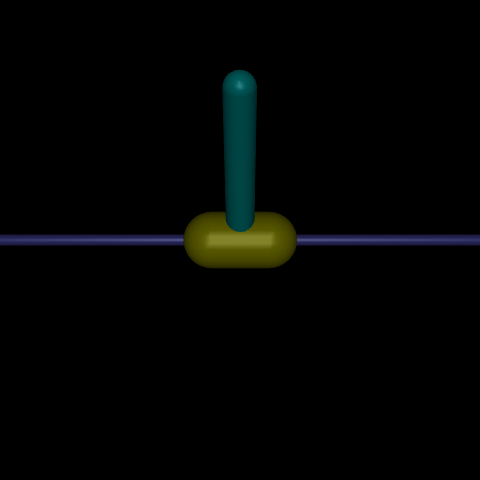

In [9]:
# POST-TRAINING: Visualise the learned policy
import imageio

def evaluate_and_gif(agent, env_id, device, path='/kaggle/working/pendulum_learned.gif',
                     n_episodes=3, max_steps=1000):
    """
    Runs n_episodes with the trained (greedy) policy,
    saves all frames as a GIF, and displays it inline.
    """
    eval_env = gym.make(env_id, render_mode="rgb_array")
    frames   = []
    ep_returns = []

    for ep in range(n_episodes):
        obs, _ = eval_env.reset(seed=ep * 7)
        ep_ret = 0.0
        for step in range(max_steps):
            # Greedy action — no sampling, use the mean directly
            # [ASSUMPTION being relaxed here: we turn off stochasticity at test time]
            with torch.no_grad():
                t = torch.tensor(obs, dtype=torch.float32).unsqueeze(0).to(device)
                # Use mean action directly instead of sampling from the distribution
                action = agent.actor_mean(t)
                action = action.cpu().numpy().reshape(-1)

            obs, rew, term, trunc, _ = eval_env.step(action)
            ep_ret += rew
            frames.append(eval_env.render())

            if term or trunc:
                break

        ep_returns.append(ep_ret)
        print(f"  Episode {ep+1}: Return = {ep_ret:.1f}  "
              f"({'SOLVED ✓' if ep_ret >= 950 else 'partial'})")

    eval_env.close()

    # Save as GIF
    imageio.mimsave(path, frames, fps=30)
    print(f"\nGIF saved → {path}")
    print(f"Mean return across {n_episodes} episodes: {np.mean(ep_returns):.1f}")
    print(f"(Max possible = 1000)")

    # Display inline in Kaggle
    from IPython.display import Image as IPImage
    display(IPImage(path))


# Install imageio if not present
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "imageio"], 
               capture_output=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
evaluate_and_gif(agent, ENV_ID, device)

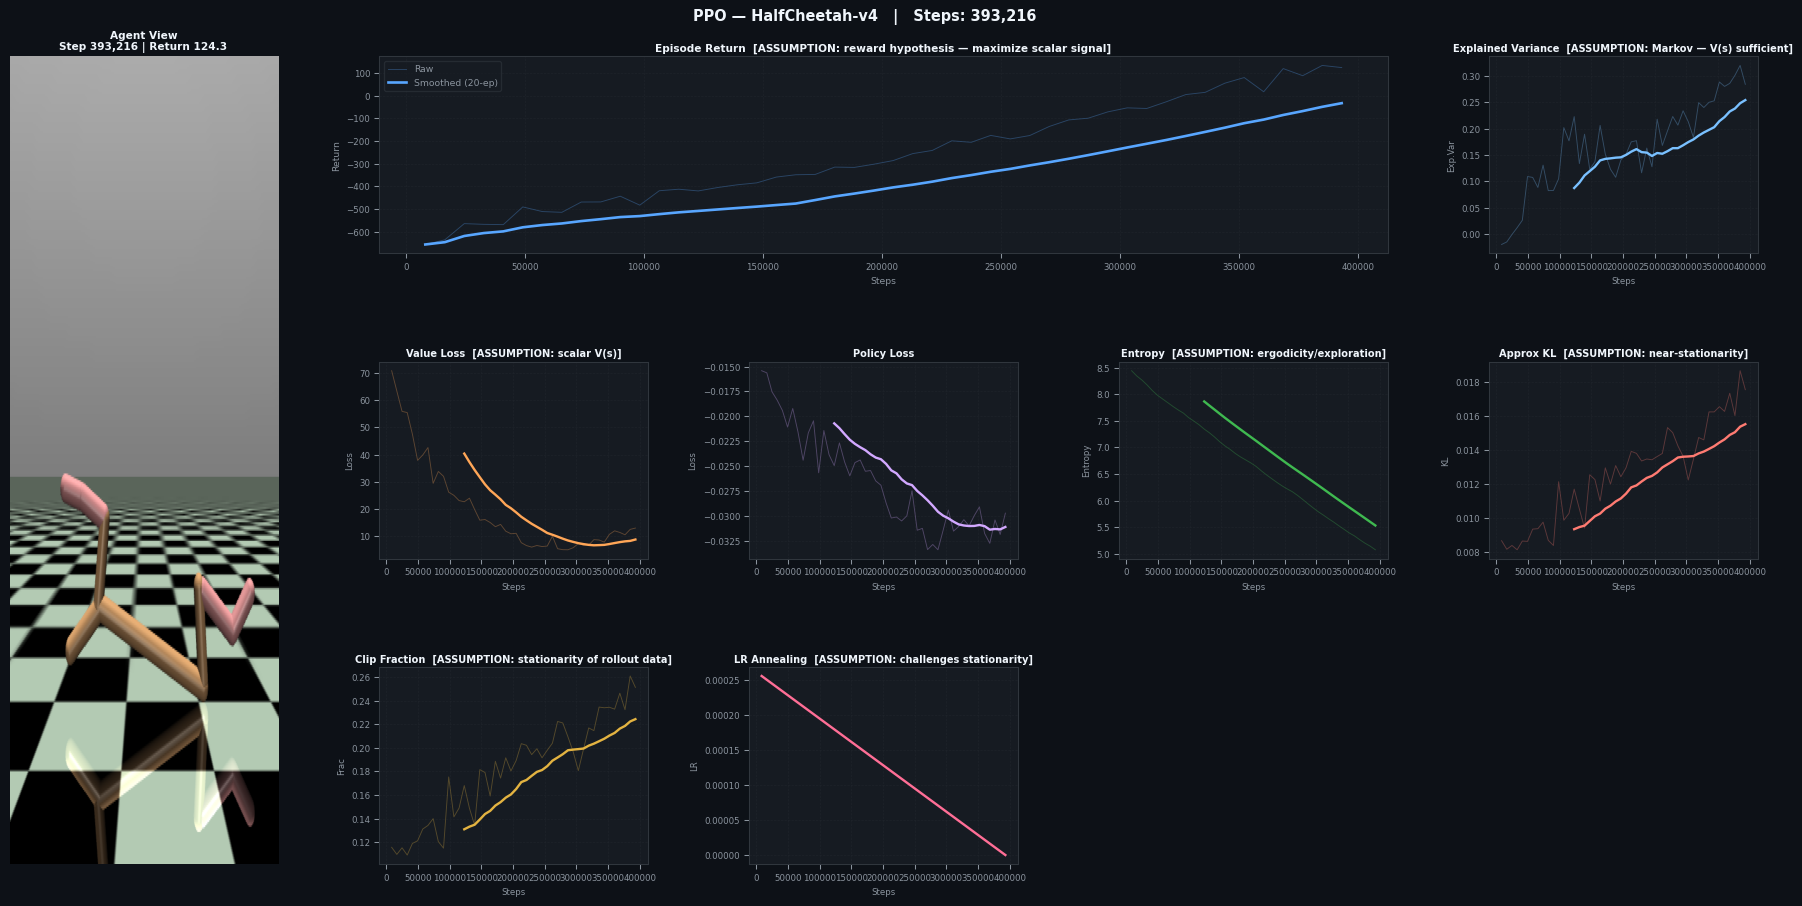

In [ ]:
import os
os.environ["MUJOCO_GL"]         = "osmesa"
os.environ["PYOPENGL_PLATFORM"] = "osmesa"
os.environ["LD_PRELOAD"]        = ""

import subprocess, sys

IN_KAGGLE = os.path.exists('/kaggle/working')
if IN_KAGGLE:
    subprocess.run(["apt-get", "install", "-y", "-q",
                    "libgl1-mesa-glx", "libosmesa6", "libosmesa6-dev",
                    "libglfw3"], capture_output=True)
    print("✓ System GL libraries ready")

def pip(pkg):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg],
                   capture_output=True)

pip("gymnasium")
pip("gymnasium[mujoco]")
pip("torch")
pip("numpy")
pip("matplotlib")
pip("pillow")
pip("imageio")
print("✓ Python dependencies ready")

import time, random, io, warnings
warnings.filterwarnings('ignore')

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions.normal import Normal
from torch.distributions.categorical import Categorical

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import deque

from IPython.display import display, clear_output
from PIL import Image

# Detect environment
try:
    import gymnasium as gym
    _e = gym.make("HalfCheetah-v4", render_mode="rgb_array")
    _e.reset()
    _e.close()
    ENV_ID        = "HalfCheetah-v4"
    IS_CONTINUOUS = True
    print("✓ MuJoCo found — using HalfCheetah-v4")
except Exception:
    import gymnasium as gym
    ENV_ID        = "CartPole-v1"
    IS_CONTINUOUS = False
    print("ℹ MuJoCo not available — falling back to CartPole-v1")

# Hyperparams
SEED            = 42
TOTAL_TIMESTEPS = 3_000_000 if IS_CONTINUOUS else 150_000
NUM_ENVS        = 4
# Larger rollout = more complete HalfCheetah episodes per update
# (episodes are 1000 steps; 4 envs × 2048 = ~8 episodes per update)
NUM_STEPS       = 2048    # [ASSUMPTION: episodic/finite horizon]
MINIBATCH_SIZE  = 512
UPDATE_EPOCHS   = 10
GAMMA           = 0.99    # [ASSUMPTION: geometric discount]
GAE_LAMBDA      = 0.95
CLIP_COEF       = 0.2     # [ASSUMPTION: near-stationarity / trust region]
ENT_COEF        = 0.0
VF_COEF         = 0.5
MAX_GRAD_NORM   = 0.5
LR              = 3e-4
ANNEAL_LR       = True    # [ASSUMPTION: mild non-stationarity via lr decay]
PLOT_EVERY      = 1
RENDER_EVERY    = 20

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# NNs
def layer_init(layer, std=np.sqrt(2), bias_const=0.0):
    nn.init.orthogonal_(layer.weight, std)
    nn.init.constant_(layer.bias, bias_const)
    return layer


class AgentContinuous(nn.Module):
    """
    [ASSUMPTION: Full observability  — raw state vector, no belief state]
    [ASSUMPTION: Markov property     — only current obs, zero history]
    [ASSUMPTION: Scalar reward       — single value head V(s)]
    [ASSUMPTION: Known action space  — act_dim fixed at init]
    """
    def __init__(self, obs_dim, act_dim):
        super().__init__()
        self.critic = nn.Sequential(
            layer_init(nn.Linear(obs_dim, 256)), nn.Tanh(),
            layer_init(nn.Linear(256, 256)),     nn.Tanh(),
            layer_init(nn.Linear(256, 1), std=1.0),
        )
        self.actor_mean = nn.Sequential(
            layer_init(nn.Linear(obs_dim, 256)), nn.Tanh(),
            layer_init(nn.Linear(256, 256)),     nn.Tanh(),
            layer_init(nn.Linear(256, act_dim), std=0.01),
        )
        self.actor_log_std = nn.Parameter(torch.zeros(1, act_dim))

    def get_value(self, x):
        return self.critic(x)

    def get_action_and_value(self, x, action=None):
        mean = self.actor_mean(x)
        std  = torch.exp(self.actor_log_std.expand_as(mean))
        dist = Normal(mean, std)
        if action is None:
            action = dist.sample()
        return action, dist.log_prob(action).sum(1), dist.entropy().sum(1), self.critic(x)


class AgentDiscrete(nn.Module):
    # CartPole fallback
    def __init__(self, obs_dim, act_dim):
        super().__init__()
        self.net    = nn.Sequential(
            layer_init(nn.Linear(obs_dim, 64)), nn.Tanh(),
            layer_init(nn.Linear(64, 64)),      nn.Tanh(),
        )
        self.actor  = layer_init(nn.Linear(64, act_dim), std=0.01)
        self.critic = layer_init(nn.Linear(64, 1),       std=1.0)

    def get_value(self, x):
        return self.critic(self.net(x))

    def get_action_and_value(self, x, action=None):
        h    = self.net(x)
        dist = Categorical(logits=self.actor(h))
        if action is None:
            action = dist.sample()
        return action, dist.log_prob(action), dist.entropy(), self.critic(h)


# Live Dashboard
class LivePlotter:
    BG     = '#0d1117'
    PANEL  = '#161b22'
    BORDER = '#30363d'
    GRID   = '#21262d'
    TEXT   = '#f0f6fc'
    MUTED  = '#8b949e'
    BLUE   = '#58a6ff'
    ORANGE = '#ffa657'
    PURPLE = '#d2a8ff'
    GREEN  = '#3fb950'
    RED    = '#ff7b72'
    YELLOW = '#e3b341'
    CYAN   = '#79c0ff'

    def __init__(self):
        self.steps = [];      self.returns = [];    self.ret_smooth = []
        self.v_losses = [];   self.p_losses = [];   self.entropies = []
        self.kls = [];        self.clipfracs = [];  self.expvars = []
        self.recent_ret = deque(maxlen=20)
        self.last_frame = None

    def _make_fig(self):
        fig = plt.figure(figsize=(20, 10), facecolor=self.BG)
        gs  = gridspec.GridSpec(3, 5, figure=fig,
                                hspace=0.55, wspace=0.38,
                                left=0.05, right=0.97,
                                top=0.93,  bottom=0.08)
        ax_frame = fig.add_subplot(gs[:, 0])
        ax_frame.set_facecolor('#000000'); ax_frame.axis('off')
        ax_ret = fig.add_subplot(gs[0, 1:4])
        ax_ev  = fig.add_subplot(gs[0, 4])
        ax_vl  = fig.add_subplot(gs[1, 1])
        ax_pl  = fig.add_subplot(gs[1, 2])
        ax_ent = fig.add_subplot(gs[1, 3])
        ax_kl  = fig.add_subplot(gs[1, 4])
        ax_cf  = fig.add_subplot(gs[2, 1])
        ax_lr  = fig.add_subplot(gs[2, 2])
        for ax in [ax_ret, ax_ev, ax_vl, ax_pl, ax_ent, ax_kl, ax_cf, ax_lr]:
            ax.set_facecolor(self.PANEL)
            ax.grid(True, color=self.GRID, linewidth=0.5, linestyle='--', alpha=0.7)
            for sp in ax.spines.values(): sp.set_color(self.BORDER)
            ax.tick_params(colors=self.MUTED, labelsize=6.5)
        return fig, ax_frame, ax_ret, ax_ev, ax_vl, ax_pl, ax_ent, ax_kl, ax_cf, ax_lr

    def _smooth(self, y, w=15):
        if len(y) < w: return np.array(y)
        return np.convolve(y, np.ones(w) / w, mode='valid')

    def _plot(self, ax, y, color, title, ylabel=''):
        ax.cla()
        ax.set_facecolor(self.PANEL)
        ax.grid(True, color=self.GRID, linewidth=0.5, linestyle='--', alpha=0.7)
        for sp in ax.spines.values(): sp.set_color(self.BORDER)
        ax.tick_params(colors=self.MUTED, labelsize=6.5)
        s = self.steps
        ax.plot(s, y, color=color, linewidth=0.7, alpha=0.3)
        sm = self._smooth(y)
        if len(sm): ax.plot(s[max(0, len(s)-len(sm)):], sm, color=color, lw=1.8)
        ax.set_title(title, color=self.TEXT, fontsize=7.5, fontweight='bold', pad=4)
        ax.set_ylabel(ylabel, color=self.MUTED, fontsize=6.5)
        ax.set_xlabel('Steps', color=self.MUTED, fontsize=6.5)

    def update(self, step, ep_return, v_loss, p_loss,
               entropy, kl, clipfrac, expvar, lr, frame=None):

        self.steps.append(step)
        self.returns.append(ep_return)
        self.recent_ret.append(ep_return)
        self.ret_smooth.append(float(np.mean(self.recent_ret)))
        self.v_losses.append(v_loss);    self.p_losses.append(p_loss)
        self.entropies.append(entropy);  self.kls.append(kl)
        self.clipfracs.append(clipfrac); self.expvars.append(expvar)
        if frame is not None:
            self.last_frame = frame

        fig, ax_frame, ax_ret, ax_ev, ax_vl, ax_pl, ax_ent, ax_kl, ax_cf, ax_lr \
            = self._make_fig()
        s = self.steps

        # Env frame
        ax_frame.cla(); ax_frame.axis('off')
        ax_frame.set_facecolor('#000000')
        if self.last_frame is not None:
            ax_frame.imshow(self.last_frame, aspect='auto')
        else:
            ax_frame.text(0.5, 0.5, 'Waiting\nfor frame…',
                          ha='center', va='center', color=self.MUTED,
                          fontsize=11, transform=ax_frame.transAxes)
        ax_frame.set_title(f'Agent View\nStep {step:,} | Return {ep_return:.1f}',
                           color=self.TEXT, fontsize=8, fontweight='bold', pad=5)

        # Return
        ax_ret.cla(); ax_ret.set_facecolor(self.PANEL)
        ax_ret.grid(True, color=self.GRID, linewidth=0.5, linestyle='--', alpha=0.7)
        for sp in ax_ret.spines.values(): sp.set_color(self.BORDER)
        ax_ret.tick_params(colors=self.MUTED, labelsize=6.5)
        ax_ret.plot(s, self.returns,    color=self.BLUE, lw=0.7, alpha=0.3, label='Raw')
        ax_ret.plot(s, self.ret_smooth, color=self.BLUE, lw=2.0,            label='Smoothed (20-ep)')
        ax_ret.set_title('Episode Return  [ASSUMPTION: reward hypothesis — maximize scalar signal]',
                         color=self.TEXT, fontsize=8, fontweight='bold', pad=4)
        ax_ret.set_ylabel('Return', color=self.MUTED, fontsize=7)
        ax_ret.set_xlabel('Steps',  color=self.MUTED, fontsize=7)
        ax_ret.legend(fontsize=7, facecolor=self.PANEL, labelcolor=self.MUTED,
                      framealpha=0.6, edgecolor=self.BORDER)

        self._plot(ax_ev,  self.expvars,   self.CYAN,
                   'Explained Variance  [ASSUMPTION: Markov — V(s) sufficient]', 'Exp.Var')
        self._plot(ax_vl,  self.v_losses,  self.ORANGE,
                   'Value Loss  [ASSUMPTION: scalar V(s)]', 'Loss')
        self._plot(ax_pl,  self.p_losses,  self.PURPLE,
                   'Policy Loss', 'Loss')
        self._plot(ax_ent, self.entropies, self.GREEN,
                   'Entropy  [ASSUMPTION: ergodicity/exploration]', 'Entropy')
        self._plot(ax_kl,  self.kls,       self.RED,
                   'Approx KL  [ASSUMPTION: near-stationarity]', 'KL')
        self._plot(ax_cf,  self.clipfracs, self.YELLOW,
                   'Clip Fraction  [ASSUMPTION: stationarity of rollout data]', 'Frac')

        # LR annealing
        ax_lr.cla(); ax_lr.set_facecolor(self.PANEL)
        ax_lr.grid(True, color=self.GRID, linewidth=0.5, linestyle='--', alpha=0.7)
        for sp in ax_lr.spines.values(): sp.set_color(self.BORDER)
        ax_lr.tick_params(colors=self.MUTED, labelsize=6.5)
        max_s = max(self.steps) if self.steps else 1
        ax_lr.plot(s, [lr * (1 - st/max_s) for st in s], color='#ff6e96', lw=1.8)
        ax_lr.set_title('LR Annealing  [ASSUMPTION: challenges stationarity]',
                        color=self.TEXT, fontsize=7.5, fontweight='bold', pad=4)
        ax_lr.set_ylabel('LR', color=self.MUTED, fontsize=6.5)
        ax_lr.set_xlabel('Steps', color=self.MUTED, fontsize=6.5)

        fig.suptitle(f'PPO — {ENV_ID}   |   Steps: {step:,}',
                     color=self.TEXT, fontsize=11, fontweight='bold', y=0.98)

        buf = io.BytesIO()
        fig.savefig(buf, format='png', dpi=95, bbox_inches='tight', facecolor=self.BG)
        buf.seek(0); plt.close(fig)
        clear_output(wait=True)
        display(Image.open(buf))


# Env factory
def make_env(env_id, seed, idx):
    def thunk():
        e = gym.make(env_id)
        e = gym.wrappers.RecordEpisodeStatistics(e)
        e.reset(seed=seed + idx)
        return e
    return thunk


# Training
def train():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"\nDevice : {device}  |  Env : {ENV_ID}  |  Steps : {TOTAL_TIMESTEPS:,}\n")

    # [ASSUMPTION: single-agent — parallel envs are independent copies]
    envs = gym.vector.SyncVectorEnv(
        [make_env(ENV_ID, SEED, i) for i in range(NUM_ENVS)]
    )
    obs_dim = int(np.prod(envs.single_observation_space.shape))
    act_dim = (int(np.prod(envs.single_action_space.shape))
               if IS_CONTINUOUS else envs.single_action_space.n)

    Agent = AgentContinuous if IS_CONTINUOUS else AgentDiscrete
    agent = Agent(obs_dim, act_dim).to(device)
    optimizer = optim.Adam(agent.parameters(), lr=LR, eps=1e-5)

    render_env = gym.make(ENV_ID, render_mode="rgb_array")

    # [ASSUMPTION: episodic/finite horizon — fixed-size rollout buffers]
    act_shape = (act_dim,) if IS_CONTINUOUS else ()
    obs_buf  = torch.zeros(NUM_STEPS, NUM_ENVS, obs_dim).to(device)
    act_buf  = torch.zeros(NUM_STEPS, NUM_ENVS, *act_shape).to(device)
    logp_buf = torch.zeros(NUM_STEPS, NUM_ENVS).to(device)
    rew_buf  = torch.zeros(NUM_STEPS, NUM_ENVS).to(device)
    done_buf = torch.zeros(NUM_STEPS, NUM_ENVS).to(device)
    val_buf  = torch.zeros(NUM_STEPS, NUM_ENVS).to(device)

    plotter     = LivePlotter()
    global_step = 0
    num_updates = TOTAL_TIMESTEPS // (NUM_ENVS * NUM_STEPS)
    start_time  = time.time()

    obs, _ = envs.reset(seed=SEED)
    obs    = torch.tensor(obs, dtype=torch.float32).to(device)
    done   = torch.zeros(NUM_ENVS).to(device)
    current_frame = None

    print(f"{num_updates} updates × {NUM_STEPS} steps × {NUM_ENVS} envs")
    print(f"~{NUM_ENVS * NUM_STEPS // 1000}k steps per update  |  "
          f"~{NUM_ENVS * NUM_STEPS // 1000} HalfCheetah episodes per update")
    print("─" * 70)
    print(f"{'Update':>8} {'Steps':>10} {'Return':>10} "
          f"{'VLoss':>8} {'KL':>7} {'ExpVar':>8} {'SPS':>7}")
    print("─" * 70)

    for update in range(1, num_updates + 1):

        # [ASSUMPTION: mild non-stationarity — lr decays linearly]
        if ANNEAL_LR:
            frac = 1.0 - (update - 1.0) / num_updates
            current_lr = frac * LR
            optimizer.param_groups[0]["lr"] = current_lr
        else:
            current_lr = LR

        # Capture render frame
        # render() called INSIDE step loop — calling after episode
        # ends returns None on some gymnasium versions
        if update % RENDER_EVERY == 0 or update == 1:
            try:
                r_obs, _ = render_env.reset()
                latest_frame = None
                for _ in range(1000):
                    with torch.no_grad():
                        t = torch.tensor(r_obs, dtype=torch.float32).unsqueeze(0).to(device)
                        a, _, _, _ = agent.get_action_and_value(t)
                    # reshape(-1) avoids squeeze() collapsing act_dim=1 to scalar
                    r_obs, _, rt, ru, _ = render_env.step(
                        a.cpu().numpy().reshape(-1) if IS_CONTINUOUS else int(a.item())
                    )
                    latest_frame = render_env.render()
                    if rt or ru:
                        break
                if latest_frame is not None:
                    current_frame = latest_frame
            except Exception as e:
                print(f"  Render warning: {e}")

        # Rollout collection
        # [ASSUMPTION: Markov — only obs[t], no history]
        # [ASSUMPTION: full observability — raw state vector]
        ep_returns = []
        for step in range(NUM_STEPS):
            global_step += NUM_ENVS
            obs_buf[step]  = obs
            done_buf[step] = done

            with torch.no_grad():
                action, logp, _, value = agent.get_action_and_value(obs)
                val_buf[step] = value.flatten()

            act_buf[step]  = action
            logp_buf[step] = logp

            obs_np, rew, term, trunc, info = envs.step(action.cpu().numpy())

            # [ASSUMPTION: scalar reward — single float per env per step]
            rew_buf[step] = torch.tensor(rew, dtype=torch.float32).to(device)
            done = torch.tensor(np.logical_or(term, trunc),
                                dtype=torch.float32).to(device)
            obs  = torch.tensor(obs_np, dtype=torch.float32).to(device)

            # gymnasium vectorenv uses _episode mask (not final_info)
            if "_episode" in info:
                for i, finished in enumerate(info["_episode"]):
                    if finished:
                        ep_returns.append(float(info["episode"]["r"][i]))

        # GAE
        # [ASSUMPTION: Markov — bootstrap from V(s_{t+1})]
        # [ASSUMPTION: geometric discount γ]
        # [ASSUMPTION: stationarity — V(s) fixed during bootstrap]
        with torch.no_grad():
            next_val   = agent.get_value(obs).reshape(1, -1)
            advantages = torch.zeros_like(rew_buf).to(device)
            gae = 0.0
            for t in reversed(range(NUM_STEPS)):
                nnt   = 1.0 - (done if t == NUM_STEPS-1 else done_buf[t+1])
                nv    = next_val if t == NUM_STEPS-1 else val_buf[t+1]
                delta = rew_buf[t] + GAMMA * nv * nnt - val_buf[t]
                gae   = delta + GAMMA * GAE_LAMBDA * nnt * gae
                advantages[t] = gae
            returns = advantages + val_buf

        # PPO Update
        # [ASSUMPTION: reward hypothesis — single scalar loss]
        # [ASSUMPTION: single agent]
        b_obs  = obs_buf.reshape(-1, obs_dim)
        b_act  = act_buf.reshape(-1, *act_buf.shape[2:])
        b_logp = logp_buf.reshape(-1)
        b_adv  = advantages.reshape(-1)
        b_ret  = returns.reshape(-1)
        b_val  = val_buf.reshape(-1)

        cf_list, vl_list, pl_list, ent_list, kl_list = [], [], [], [], []

        for _ in range(UPDATE_EPOCHS):
            idx = np.random.permutation(NUM_STEPS * NUM_ENVS)
            for start in range(0, NUM_STEPS * NUM_ENVS, MINIBATCH_SIZE):
                mb   = idx[start:start + MINIBATCH_SIZE]
                mb_o = b_obs[mb];  mb_a = b_act[mb]
                mb_lp= b_logp[mb]; mb_ad= b_adv[mb]
                mb_r = b_ret[mb];  mb_v = b_val[mb]

                _, nlp, ent, nv = agent.get_action_and_value(
                    mb_o, mb_a if IS_CONTINUOUS else mb_a.long()
                )
                nv = nv.flatten()
                log_ratio = nlp - mb_lp
                ratio     = log_ratio.exp()

                with torch.no_grad():
                    kl = ((ratio - 1) - log_ratio).mean()
                    cf_list.append(((ratio - 1.0).abs() > CLIP_COEF).float().mean().item())

                # [ASSUMPTION: local stationarity — adv normalised within minibatch]
                mb_ad = (mb_ad - mb_ad.mean()) / (mb_ad.std() + 1e-8)

                pg1 = -mb_ad * ratio
                pg2 = -mb_ad * torch.clamp(ratio, 1-CLIP_COEF, 1+CLIP_COEF)
                pl  = torch.max(pg1, pg2).mean()

                # [ASSUMPTION: scalar V(s)]
                v_unc = (nv - mb_r) ** 2
                v_clp = mb_v + torch.clamp(nv - mb_v, -CLIP_COEF, CLIP_COEF)
                vl    = 0.5 * torch.max(v_unc, (v_clp - mb_r) ** 2).mean()

                # [ASSUMPTION: ergodicity — entropy keeps exploration alive]
                el   = ent.mean()
                loss = pl + VF_COEF * vl - ENT_COEF * el

                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(agent.parameters(), MAX_GRAD_NORM)
                optimizer.step()

                vl_list.append(vl.item()); pl_list.append(pl.item())
                ent_list.append(el.item()); kl_list.append(kl.item())

        # Explained variance
        # [ASSUMPTION: Markov — high expvar = V(s) captures returns well]
        yp = b_val.cpu().numpy(); yt = b_ret.cpu().numpy()
        vy = np.var(yt)
        ev = float(1 - np.var(yt - yp) / vy) if vy > 0 else 0.0

        sps = int(global_step / (time.time() - start_time))

        # safe_return: use mean of completed episodes this update,
        # or last known return if no episode finished (common early in HalfCheetah)
        safe_return = (float(np.mean(ep_returns)) if ep_returns
                       else (plotter.returns[-1] if plotter.returns else 0.0))

        if update % 5 == 0 or update == 1:
            print(f"{update:>8}/{num_updates} "
                  f"{global_step:>10,} "
                  f"{safe_return:>10.1f} "
                  f"{np.mean(vl_list):>8.4f} "
                  f"{np.mean(kl_list):>7.4f} "
                  f"{ev:>8.3f} "
                  f"{sps:>7,}")

        if update % PLOT_EVERY == 0:
            plotter.update(
                step     = global_step,
                ep_return= safe_return,
                v_loss   = float(np.mean(vl_list)),
                p_loss   = float(np.mean(pl_list)),
                entropy  = float(np.mean(ent_list)),
                kl       = float(np.mean(kl_list)),
                clipfrac = float(np.mean(cf_list)),
                expvar   = ev,
                lr       = current_lr,
                frame    = current_frame,
            )

    envs.close()
    render_env.close()

    # Final dashboard flush
    if plotter.steps:
        plotter.update(
            step     = global_step,
            ep_return= plotter.returns[-1],
            v_loss   = plotter.v_losses[-1],
            p_loss   = plotter.p_losses[-1],
            entropy  = plotter.entropies[-1],
            kl       = plotter.kls[-1],
            clipfrac = plotter.clipfracs[-1],
            expvar   = plotter.expvars[-1],
            lr       = 0.0,
            frame    = current_frame,
        )

    print("\n" + "="*70)
    print("Training complete!")
    return agent   # returned so evaluate_and_gif() can use it directly


# Train
agent = train()


# Post-training evaluation
# Runs 3 greedy episodes, saves a GIF, displays it inline.
# Uses actor_mean directly (deterministic) instead of sampling —
# this deliberately relaxes the exploration/ergodicity assumption.

import imageio

def evaluate_and_gif(agent, env_id, device,
                     path='/kaggle/working/cheetah_learned.gif',
                     n_episodes=3, max_steps=1000):

    print(f"\nEvaluating trained policy — {n_episodes} episodes...")
    eval_env   = gym.make(env_id, render_mode="rgb_array")
    frames     = []
    ep_returns = []

    for ep in range(n_episodes):
        obs, _ = eval_env.reset(seed=ep * 7)
        ep_ret = 0.0
        for _ in range(max_steps):
            with torch.no_grad():
                t      = torch.tensor(obs, dtype=torch.float32).unsqueeze(0).to(device)
                action = agent.actor_mean(t)        # greedy: mean of Gaussian, no sampling
                action = action.cpu().numpy().reshape(-1)
            obs, rew, term, trunc, _ = eval_env.step(action)
            ep_ret += rew
            frames.append(eval_env.render())
            if term or trunc:
                break

        ep_returns.append(ep_ret)
        print(f"  Episode {ep+1}: Return = {ep_ret:.1f}  "
              f"({'good ✓' if ep_ret > 1000 else 'still learning' if ep_ret > 0 else 'negative'})")

    eval_env.close()

    imageio.mimsave(path, frames, fps=30)
    print(f"\nGIF saved → {path}")
    print(f"Mean return : {np.mean(ep_returns):.1f}  "
          f"(3M-step PPO typically reaches 3000–5000)")

    from IPython.display import Image as IPImage
    display(IPImage(path))


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
evaluate_and_gif(agent, ENV_ID, device)